# Reconstructions of protein structures based on boolean contact maps [0, 1]
## Contact maps are use as contraints in a gradient-based optimization function

In [1]:
import pickle as pkl
import math
from scipy.spatial.distance import cdist
import time
import numpy as np
import matplotlib.pyplot as plt
import importlib, sys, os

import torch
import torch.nn.functional as F

import random
random.seed(42)

# Import Data

In [2]:
parent_folder = "..\..\..\code\dataset\\nanos_networkx_small\processed_data"
folders = [name for name in os.listdir(parent_folder) 
           if os.path.isdir(os.path.join(parent_folder, name))]

print(len(folders))

3024


In [3]:
cwd = os.getcwd()
print(cwd)

c:\Users\laran\Documents\Git\CAS_AML_Final_Project\gradient_optimization


# Protein class definition

In [4]:
if 'classes.proteins' in sys.modules: importlib.reload(sys.modules['classes.proteins'])
from classes.proteins import *

# Database generation

In [5]:
random.seed(42)

PROTEINS = Database()
SUBPROTEINS = Database()

chunk_length = 50   

for folder in folders:
    filename = f"{cwd}/{parent_folder}/{folder}/{folder}{folder[-2:]}_atoms.pkl"
    try:
        with open(filename, 'rb') as f:
            data = pkl.load(f)
            protein = Protein(data)
            PROTEINS.append(protein)
    except EOFError:
            print(f"Error: {filename} is empty or corrupted")
            continue  # Skip the file and goes to the next
            
    aas, cas, previous_aa = protein.explode(chunk_length)
    for i in range(len(aas)):
        subprotein = Protein(aas=aas[i], cas=cas[i], previous_aa=[previous_aa[i]])
        SUBPROTEINS.append(subprotein)

SUBPROTEINS.randomize

print (f"{SUBPROTEINS.len} items in full")
SUBPROTEINS = SUBPROTEINS[:10000]
print (f"{SUBPROTEINS.len} items in database")

Error: c:\Users\laran\Documents\Git\CAS_AML_Final_Project\gradient_optimization/..\..\..\code\dataset\nanos_networkx_small\processed_data/2P43_nanobody_B/2P43_nanobody_B_B_atoms.pkl is empty or corrupted
Error: c:\Users\laran\Documents\Git\CAS_AML_Final_Project\gradient_optimization/..\..\..\code\dataset\nanos_networkx_small\processed_data/5JDS_nanobody_B/5JDS_nanobody_B_B_atoms.pkl is empty or corrupted
Error: c:\Users\laran\Documents\Git\CAS_AML_Final_Project\gradient_optimization/..\..\..\code\dataset\nanos_networkx_small\processed_data/6IBL_nanobody_C/6IBL_nanobody_C_C_atoms.pkl is empty or corrupted
Error: c:\Users\laran\Documents\Git\CAS_AML_Final_Project\gradient_optimization/..\..\..\code\dataset\nanos_networkx_small\processed_data/6RPJ_nanobody_D/6RPJ_nanobody_D_D_atoms.pkl is empty or corrupted
Error: c:\Users\laran\Documents\Git\CAS_AML_Final_Project\gradient_optimization/..\..\..\code\dataset\nanos_networkx_small\processed_data/6X07_nanobody_B/6X07_nanobody_B_B_atoms.pkl is

# Contact maps definition (y data) and reconstrcution test

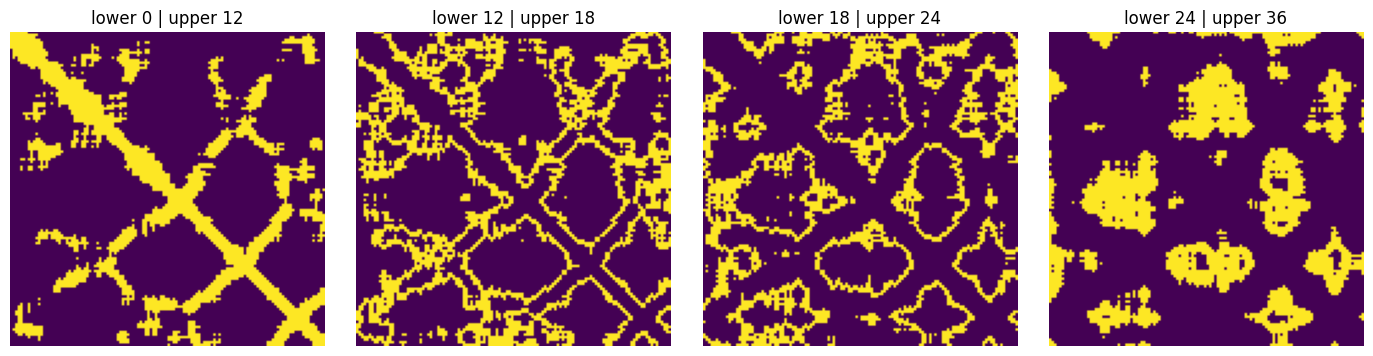

In [6]:
if 'functions.misc' in sys.modules: importlib.reload(sys.modules['functions.misc'])
from functions.misc import *

protein = PROTEINS[0]
CONFIGS = []
CONFIGS.append({'lower':0, 'upper':12})
CONFIGS.append({'lower':12, 'upper':18})
CONFIGS.append({'lower':18, 'upper':24})
CONFIGS.append({'lower':24, 'upper':36})

cmaps = [protein.add_contact_map(config['lower'], config['upper'], False) for config in CONFIGS]
titles = [f"lower {config['lower']} | upper {config['upper']}" for config in CONFIGS]
compare_images(cmaps, titles, masking=False)

In [7]:
if 'functions.misc' in sys.modules: importlib.reload(sys.modules['functions.misc'])

from functions.misc import *

orig_cmap_recon_coords = reconstruct_coords_local_plural_maps(cmaps, CONFIGS, sharpness=15., window=25, 
                                                              dim=3, lr=1e-2, max_iter=10000, prints=10)

Gradient-based optimization with multiple contact maps...
Step       0 | total loss:    58.91 (['    5.36', '   12.29', '   11.32', '   27.50'])
Step    1000 | total loss:     3.85 (['    0.51', '    0.76', '    0.79', '    1.55'])
Step    2000 | total loss:     0.31 (['    0.02', '    0.05', '    0.08', '    0.14'])
Step    3000 | total loss:     0.02 (['    0.00', '    0.01', '    0.01', '    0.00'])
Step    4000 | total loss:     0.01 (['    0.00', '    0.00', '    0.00', '    0.00'])
Step    5000 | total loss:     0.01 (['    0.00', '    0.00', '    0.00', '    0.00'])
Step    6000 | total loss:     0.01 (['    0.00', '    0.00', '    0.00', '    0.00'])
Step    7000 | total loss:     0.01 (['    0.00', '    0.00', '    0.00', '    0.00'])
Step    8000 | total loss:     0.01 (['    0.00', '    0.00', '    0.00', '    0.00'])
Step    9000 | total loss:     0.01 (['    0.00', '    0.00', '    0.00', '    0.00'])
Step    9999 | total loss:     0.01 (['    0.00', '    0.00', '    0.00'

In [8]:
if 'functions.graphics' in sys.modules: importlib.reload(sys.modules['functions.graphics'])
from functions.graphics import *

plotly_2_graphs([np.array(protein.ca), orig_cmap_recon_coords], 'Reconstruction test from true contact maps')

In [9]:
if 'functions.misc' in sys.modules: importlib.reload(sys.modules['functions.misc'])
from functions.misc import *

for protein in PROTEINS:
    for config in CONFIGS:
        protein.add_contact_map(config['lower'], config['upper'], True)
    
for protein in SUBPROTEINS:
    for config in CONFIGS:
        protein.add_contact_map(config['lower'], config['upper'], True)

# Multi-modal voxelised representation

In [10]:
class VoxelizedProteinRepresentation:
    def __init__(self, protein_data, voxel_size=1.0):
        self.voxel_size = voxel_size
        self.protein_data = protein_data
        
    def create_voxel_grid(self, coords, properties):
        """Create a 3D voxel grid with multiple channels for different properties"""
        # Find bounds
        min_coords = np.min(coords, axis=0)
        max_coords = np.max(coords, axis=0)
        
        # Create grid dimensions
        grid_size = np.ceil((max_coords - min_coords) / self.voxel_size).astype(int)
        
        # Initialize multi-channel voxel grid
        voxel_grid = np.zeros((*grid_size, len(properties)))
        
        # Fill voxels
        for i, coord in enumerate(coords):
            voxel_idx = ((coord - min_coords) / self.voxel_size).astype(int)
            for j, prop in enumerate(properties):
                if i < len(prop):
                    voxel_grid[tuple(voxel_idx) + (j,)] = prop[i]
        
        return voxel_grid


In [11]:
# Let's first check what the data structure actually is
class MultiModalProteinData:
    def __init__(self, folder_path):
        self.atoms = self.load_pickle(f"{folder_path}_atoms.pkl")
        self.angles = self.load_pickle(f"{folder_path}_angles.pkl")
        self.backbone = self.load_pickle(f"{folder_path}_backbone.pkl")
        self.bond_lengths = self.load_pickle(f"{folder_path}_bond_lengths.pkl")
        self.charges = self.load_pickle(f"{folder_path}_charges.pkl")
        self.edge_pairs = self.load_pickle(f"{folder_path}_edge_pairs.pkl")
        self.hydrophobic = self.load_pickle(f"{folder_path}_hydrophobic.pkl")
        self.torsions = self.load_pickle(f"{folder_path}_torsions.pkl")
        
    def load_pickle(self, path):
        try:
            with open(path, 'rb') as f:
                return pkl.load(f)
        except:
            return None

# Let's first inspect the data structure
folder = folders[0]  # Take first folder as example
base_path = f"{cwd}/{parent_folder}/{folder}/{folder}{folder[-2:]}"
test_data = MultiModalProteinData(base_path)

# Check the structure of the atoms data
print(f"Type of atoms data: {type(test_data.atoms)}")
if test_data.atoms is not None:
    print(f"First element of atoms: {test_data.atoms[0] if len(test_data.atoms) > 0 else 'Empty'}")
    print(f"Structure: {test_data.atoms[:2] if len(test_data.atoms) > 1 else test_data.atoms}")

Type of atoms data: <class 'list'>
First element of atoms: ('A', 1, 'LYS', 'N', 'N', array([-10.829,  11.34 , -13.055], dtype=float32))
Structure: [('A', 1, 'LYS', 'N', 'N', array([-10.829,  11.34 , -13.055], dtype=float32)), ('A', 1, 'LYS', 'CA', 'C', array([ -9.797,  10.979, -14.068], dtype=float32))]


In [12]:


# # Now let's fix the EnhancedProteinReconstruction class based on the actual data structure
# class EnhancedProteinReconstruction:
#     def __init__(self, folder_path):
#         self.multi_modal_data = MultiModalProteinData(folder_path)
#         self.voxelizer = VoxelizedProteinRepresentation(self.multi_modal_data)
        
#     def create_enhanced_representation(self):
#         """Combine contact maps with voxelized multi-modal data"""
#         # Let's handle different possible data structures
#         if self.multi_modal_data.atoms is None:
#             return None
            
#         # If atoms is a tuple of tuples or similar structure
#         if isinstance(self.multi_modal_data.atoms, tuple):
#             # Check if it's a tuple of coordinates
#             if len(self.multi_modal_data.atoms) > 0 and isinstance(self.multi_modal_data.atoms[0], (tuple, list, np.ndarray)):
#                 coords = np.array(self.multi_modal_data.atoms)
#             else:
#                 # If it's a more complex structure, we need to adapt
#                 print(f"Unexpected atoms structure: {type(self.multi_modal_data.atoms)}")
#                 return None
        
#         # If atoms is a list of dictionaries (as originally expected)
#         elif isinstance(self.multi_modal_data.atoms, list) and len(self.multi_modal_data.atoms) > 0:
#             if isinstance(self.multi_modal_data.atoms[0], dict):
#                 coords = np.array([atom['coord'] for atom in self.multi_modal_data.atoms])
#             else:
#                 coords = np.array(self.multi_modal_data.atoms)
        
#         # If atoms is already a numpy array
#         elif isinstance(self.multi_modal_data.atoms, np.ndarray):
#             coords = self.multi_modal_data.atoms
        
#         else:
#             print(f"Unsupported atoms structure: {type(self.multi_modal_data.atoms)}")
#             return None
        
#         # Rest of the function remains the same...
#         return {
#             'coords': coords,
#             'raw_data': self.multi_modal_data
#         }

In [13]:
# # Self-supervised tasks using all available data
# class MultiModalSelfSupervised:
#     def __init__(self, protein_data):
#         self.data = protein_data
        
#     def mask_and_predict_task(self):
#         """Mask different modalities and predict them from others"""
#         tasks = []
        
#         # Task 1: Predict charges from structure
#         tasks.append({
#             'input': [self.data.atoms, self.data.bond_lengths, self.data.angles],
#             'target': self.data.charges,
#             'task_name': 'charge_prediction'
#         })
        
#         # Task 2: Predict hydrophobicity from structure
#         tasks.append({
#             'input': [self.data.atoms, self.data.backbone],
#             'target': self.data.hydrophobic,
#             'task_name': 'hydrophobicity_prediction'
#         })
        
#         # Task 3: Predict torsion angles from backbone
#         tasks.append({
#             'input': [self.data.backbone, self.data.bond_lengths],
#             'target': self.data.torsions,
#             'task_name': 'torsion_prediction'
#         })
        
#         return tasks
    
#     def structure_consistency_task(self):
#         """Ensure consistency between different structural representations"""
#         # Check if bond lengths match distances in atom coordinates
#         # Check if angles are consistent with atomic positions
#         # etc.
#         pass



In [14]:
class EnhancedProteinReconstruction:
    def __init__(self, folder_path):
        self.multi_modal_data = MultiModalProteinData(folder_path)
        self.voxelizer = VoxelizedProteinRepresentation(self.multi_modal_data)
        
    def create_enhanced_representation(self):
        """Combine contact maps with voxelized multi-modal data"""
        if self.multi_modal_data.atoms is None:
            return None
            
        # Extract coordinates from the tuple structure
        coords = np.array([atom[5] for atom in self.multi_modal_data.atoms])
        
        # Extract other information
        chains = [atom[0] for atom in self.multi_modal_data.atoms]
        res_nums = [atom[1] for atom in self.multi_modal_data.atoms]
        res_names = [atom[2] for atom in self.multi_modal_data.atoms]
        atom_names = [atom[3] for atom in self.multi_modal_data.atoms]
        atom_types = [atom[4] for atom in self.multi_modal_data.atoms]
        
        # Process different data types correctly
        properties = []
        property_names = []
        
        # Process charges (dict)
        if self.multi_modal_data.charges is not None and isinstance(self.multi_modal_data.charges, dict):
            charge_array = np.zeros(len(coords))
            for idx, charge in self.multi_modal_data.charges.items():
                if idx < len(charge_array):
                    charge_array[idx] = charge
            properties.append(charge_array)
            property_names.append('charges')
        
        # Process hydrophobic (set) - convert to binary array
        if self.multi_modal_data.hydrophobic is not None and isinstance(self.multi_modal_data.hydrophobic, set):
            hydrophobic_array = np.zeros(len(coords))
            for idx in self.multi_modal_data.hydrophobic:
                if idx < len(hydrophobic_array):
                    hydrophobic_array[idx] = 1
            properties.append(hydrophobic_array)
            property_names.append('hydrophobic')
        
        # Process angles (dict)
        if self.multi_modal_data.angles is not None and isinstance(self.multi_modal_data.angles, dict):
            # Angles might need special handling depending on their structure
            pass
        
        # Create contact maps at different ranges
        contact_maps = {}
        for config in CONFIGS:
            contact_maps[f"{config['lower']}-{config['upper']}"] = \
                self.create_contact_map(coords, config['lower'], config['upper'])
        
        # Create voxel representation if we have properties
        voxel_grid = None
        if properties:
            voxel_grid = self.voxelizer.create_voxel_grid(coords, properties)
        
        return {
            'coords': coords,
            'chains': chains,
            'res_nums': res_nums,
            'res_names': res_names,
            'atom_names': atom_names,
            'atom_types': atom_types,
            'contact_maps': contact_maps,
            'voxel_grid': voxel_grid,
            'property_names': property_names,
            'raw_data': self.multi_modal_data
        }
    
    def create_contact_map(self, coords, lower, upper):
        """Create contact map for given distance range"""
        distances = np.sqrt(np.sum((coords[:, None] - coords[None, :]) ** 2, axis=-1))
        contact_map = (distances >= lower) & (distances < upper)
        return contact_map.astype(float)



In [15]:
# Fix the voxelizer to handle property arrays correctly
class VoxelizedProteinRepresentation:
    def __init__(self, protein_data, voxel_size=1.0):
        self.voxel_size = voxel_size
        self.protein_data = protein_data
        
    def create_voxel_grid(self, coords, properties):
        """Create a 3D voxel grid with multiple channels for different properties"""
        # Find bounds
        min_coords = np.min(coords, axis=0)
        max_coords = np.max(coords, axis=0)
        
        # Create grid dimensions
        grid_size = np.ceil((max_coords - min_coords) / self.voxel_size).astype(int)
        
        # Initialize multi-channel voxel grid
        voxel_grid = np.zeros((*grid_size, len(properties)))
        
        # Fill voxels
        for i, coord in enumerate(coords):
            voxel_idx = ((coord - min_coords) / self.voxel_size).astype(int)
            # Ensure we don't go out of bounds
            voxel_idx = np.clip(voxel_idx, 0, grid_size - 1)
            
            for j, prop in enumerate(properties):
                if i < len(prop):
                    voxel_grid[tuple(voxel_idx) + (j,)] = prop[i]
        
        return voxel_grid



In [16]:
# Let's also inspect the structure of the dictionaries to understand their format
def inspect_dict_structure(data_dict, name, max_items=5):
    """Inspect the structure of dictionary data"""
    if isinstance(data_dict, dict):
        print(f"\n{name} structure:")
        print(f"  Number of keys: {len(data_dict)}")
        if data_dict:
            items = list(data_dict.items())[:max_items]
            for key, value in items:
                print(f"  {key}: {type(value)} - {value}")
            if len(data_dict) > max_items:
                print(f"  ... and {len(data_dict) - max_items} more items")

# Inspect the dictionary structures
folder = folders[0]
base_path = f"{cwd}/{parent_folder}/{folder}/{folder}{folder[-2:]}"
test_data = MultiModalProteinData(base_path)

inspect_dict_structure(test_data.angles, "Angles")
inspect_dict_structure(test_data.backbone, "Backbone")
inspect_dict_structure(test_data.bond_lengths, "Bond lengths")
inspect_dict_structure(test_data.charges, "Charges")
inspect_dict_structure(test_data.torsions, "Torsions")

# Now try the enhanced reconstruction
enhanced_proteins = []
for folder in folders[:1]:  # Test with first folder
    base_path = f"{cwd}/{parent_folder}/{folder}/{folder}{folder[-2:]}"
    enhanced_protein = EnhancedProteinReconstruction(base_path)
    enhanced_rep = enhanced_protein.create_enhanced_representation()
    if enhanced_rep is not None:
        enhanced_proteins.append(enhanced_rep)
        print(f"\nSuccessfully processed {folder}")
        print(f"Coords shape: {enhanced_rep['coords'].shape}")
        print(f"Available data: {list(enhanced_rep.keys())}")
        if enhanced_rep['voxel_grid'] is not None:
            print(f"Voxel grid shape: {enhanced_rep['voxel_grid'].shape}")


Angles structure:
  Number of keys: 742
  (0, 1, 2): <class 'numpy.float64'> - 111.02150913366488
  (1, 2, 3): <class 'numpy.float64'> - 121.46197611797118
  (3, 2, 0): <class 'numpy.float64'> - 135.064245555625
  (2, 0, 1): <class 'numpy.float64'> - 34.98732652334493
  (9, 10, 11): <class 'numpy.float64'> - 108.13387856337313
  ... and 737 more items

Backbone structure:
  Number of keys: 124
  1: <class 'dict'> - {'N': array([-10.829,  11.34 , -13.055], dtype=float32), 'CA': array([ -9.797,  10.979, -14.068], dtype=float32), 'C': array([ -9.13 ,   9.648, -13.721], dtype=float32), 'O': array([ -9.096,   8.716, -14.527], dtype=float32)}
  2: <class 'dict'> - {'N': array([ -8.481,   9.651, -12.552], dtype=float32), 'CA': array([ -7.79 ,   8.447, -12.085], dtype=float32), 'C': array([ -8.833,   7.49 , -11.522], dtype=float32), 'O': array([ -9.703,   7.952, -10.773], dtype=float32)}
  3: <class 'dict'> - {'N': array([ -8.76 ,   6.213, -11.872], dtype=float32), 'CA': array([ -9.737,   5.2

In [17]:
# Now try the enhanced reconstruction
enhanced_proteins = []
for folder in folders[:1]:  # Test with first folder
    base_path = f"{cwd}/{parent_folder}/{folder}/{folder}{folder[-2:]}"
    enhanced_protein = EnhancedProteinReconstruction(base_path)
    enhanced_rep = enhanced_protein.create_enhanced_representation()
    if enhanced_rep is not None:
        enhanced_proteins.append(enhanced_rep)
        print(f"\nSuccessfully processed {folder}")
        print(f"Coords shape: {enhanced_rep['coords'].shape}")
        print(f"Available data: {list(enhanced_rep.keys())}")


Successfully processed 1BZQ_nanobody_A
Coords shape: (951, 3)
Available data: ['coords', 'chains', 'res_nums', 'res_names', 'atom_names', 'atom_types', 'contact_maps', 'voxel_grid', 'property_names', 'raw_data']


# Self supervised learning for multimodal data

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [19]:
# # Original

# class ProteinDataset(Dataset):
#     def __init__(self, enhanced_proteins):
#         self.data = enhanced_proteins
        
#     def __len__(self):
#         return len(self.data)
    
#     def __getitem__(self, idx):
#         protein = self.data[idx]
        
#         # Convert to tensors
#         coords = torch.FloatTensor(protein['coords'])
        
#         # Create residue-level features
#         residue_features = self.create_residue_features(protein)
        
#         # Get contact maps for different ranges
#         contact_maps = []
#         for key, cmap in protein['contact_maps'].items():
#             contact_maps.append(torch.FloatTensor(cmap))
#         contact_maps = torch.stack(contact_maps)
        
#         # Voxel grid (if available)
#         voxel_grid = None
#         if protein['voxel_grid'] is not None:
#             voxel_grid = torch.FloatTensor(protein['voxel_grid'])
        
#         return {
#             'coords': coords,
#             'residue_features': residue_features,
#             'contact_maps': contact_maps,
#             'voxel_grid': voxel_grid
#         }
    
#     def create_residue_features(self, protein):
#         """Create feature vector for each residue"""
#         # One-hot encode amino acid types
#         aa_types = ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 
#                    'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 
#                    'TYR', 'VAL']
        
#         features = []
#         for res_name in protein['res_names']:
#             # One-hot encoding
#             one_hot = torch.zeros(len(aa_types))
#             if res_name in aa_types:
#                 one_hot[aa_types.index(res_name)] = 1
#             features.append(one_hot)
        
#         return torch.stack(features)

In [20]:
# New V1

class ProteinDataset(Dataset):
    def __init__(self, enhanced_proteins):
        self.data = enhanced_proteins
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        protein = self.data[idx]
        
        # Convert to tensors
        coords = torch.FloatTensor(protein['coords'])
        
        # Create residue-level features
        residue_features = self.create_residue_features(protein)
        
        # Get contact maps for different ranges
        contact_maps = []
        for key, cmap in protein['contact_maps'].items():
            contact_maps.append(torch.FloatTensor(cmap))
        contact_maps = torch.stack(contact_maps)
        
        # Voxel grid (if available)
        voxel_grid = None
        if protein['voxel_grid'] is not None:
            voxel_grid = torch.FloatTensor(protein['voxel_grid'])
        
        # Extract charge and hydrophobicity values
        charge_values = torch.FloatTensor(protein['charges']) if 'charges' in protein else torch.zeros(len(protein['res_names']))
        hydrophobicity_values = torch.FloatTensor(protein['hydrophobic']) if 'hydrophobic' in protein else torch.zeros(len(protein['res_names']))
        
        return {
            'coords': coords,
            'residue_features': residue_features,
            'contact_maps': contact_maps,
            'voxel_grid': voxel_grid,
            'charge_values': charge_values,
            'hydrophobicity_values': hydrophobicity_values
        }
    
    def create_residue_features(self, protein):
        """Create feature vector for each residue"""
        # One-hot encode amino acid types
        aa_types = ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 
                   'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 
                   'TYR', 'VAL']
        
        features = []
        for res_name in protein['res_names']:
            # One-hot encoding
            one_hot = torch.zeros(len(aa_types))
            if res_name in aa_types:
                one_hot[aa_types.index(res_name)] = 1
            features.append(one_hot)
        
        return torch.stack(features)

In [21]:
class SelfSupervisedProteinModel(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=128, num_heads=8):
        super().__init__()
        
        # Encoder for residue features
        self.residue_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # Graph attention for learning relationships
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        
        # Decoders for different tasks
        self.contact_decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        
        self.charge_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.hydrophobicity_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )
        
    def forward(self, residue_features, coords):
        # Ensure inputs have batch dimension
        if residue_features.dim() == 2:
            residue_features = residue_features.unsqueeze(0)
        if coords.dim() == 2:
            coords = coords.unsqueeze(0)
            
        # Encode residue features
        h = self.residue_encoder(residue_features)
        
        # Self-attention
        h_attended, _ = self.attention(h, h, h)
        
        # Remove batch dimension if it was added
        if h_attended.size(0) == 1:
            h_attended = h_attended.squeeze(0)
        
        # Predict contact maps
        n = h_attended.size(0)
        h_i = h_attended.unsqueeze(1).expand(-1, n, -1)
        h_j = h_attended.unsqueeze(0).expand(n, -1, -1)
        pair_features = torch.cat([h_i, h_j], dim=-1)
        contact_pred = self.contact_decoder(pair_features).squeeze(-1)
        
        # Predict node properties
        charge_pred = self.charge_decoder(h_attended)
        hydrophobicity_pred = self.hydrophobicity_decoder(h_attended)
        
        return {
            'contact_map': contact_pred,
            'charges': charge_pred,
            'hydrophobicity': hydrophobicity_pred
        }

In [22]:
# # Original
# # Self-supervised training tasks
# class SelfSupervisedTrainer:
#     def __init__(self, model, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
#         self.model = model.to(device)
#         self.dataset = dataset
#         self.device = device
#         self.optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        
#     def train_epoch(self, dataloader):
#         self.model.train()
#         total_loss = 0
        
#         for batch in dataloader:
#             self.optimizer.zero_grad()
            
#             # Move to device
#             residue_features = batch['residue_features'][0].to(self.device)
#             coords = batch['coords'][0].to(self.device)
#             contact_maps = batch['contact_maps'][0].to(self.device)
            
#             # Forward pass
#             outputs = self.model(residue_features, coords)
            
#             # Compute losses
#             contact_loss = F.mse_loss(outputs['contact_map'], contact_maps[0])
            
#             # You can add more losses here based on available data
#             # charge_loss = ...
#             # hydrophobicity_loss = ...
            
#             loss = contact_loss
            
#             # Backward pass
#             loss.backward()
#             self.optimizer.step()
            
#             total_loss += loss.item()
        
#         return total_loss / len(dataloader)
    
#     def mask_and_predict(self, batch):
#         """Mask part of the input and predict it"""
#         # Implement masking strategies here
#         pass

In [23]:
# # Part of the original code 
# # Self-supervised training tasks
# class SelfSupervisedTrainer:
#     def __init__(self, model, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
#         self.model = model.to(device)
#         self.dataset = dataset
#         self.device = device
#         self.optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        
#         # Loss weights - you may want to tune these
#         self.contact_weight = 1.0
#         self.charge_weight = 0.5
#         self.hydrophobicity_weight = 0.5
        
#     def train_epoch(self, dataloader):
#         self.model.train()
#         total_loss = 0
        
#         for batch in dataloader:
#             self.optimizer.zero_grad()
            
#             # Move to device
#             residue_features = batch['residue_features'][0].to(self.device)
#             coords = batch['coords'][0].to(self.device)
#             contact_maps = batch['contact_maps'][0].to(self.device)
            
#             # Get charge and hydrophobicity targets from batch
#             # Assuming these are included in your dataset
#             charge_targets = batch['charge_values'][0].to(self.device)
#             hydrophobicity_targets = batch['hydrophobicity_values'][0].to(self.device)
            
#             # Forward pass
#             outputs = self.model(residue_features, coords)
            
#             # Compute contact loss
#             contact_loss = F.mse_loss(outputs['contact_map'], contact_maps[0])
            
#             # Compute charge loss
#             # Assuming the model outputs predicted charge values
#             charge_loss = F.mse_loss(outputs['charge_pred'], charge_targets)
            
#             # Compute hydrophobicity loss
#             # Assuming the model outputs predicted hydrophobicity values
#             hydrophobicity_loss = F.mse_loss(outputs['hydrophobicity_pred'], hydrophobicity_targets)
            
#             # Combine losses with weights
#             loss = (self.contact_weight * contact_loss + 
#                     self.charge_weight * charge_loss + 
#                     self.hydrophobicity_weight * hydrophobicity_loss)
            
#             # Backward pass
#             loss.backward()
#             self.optimizer.step()
            
#             total_loss += loss.item()
            
#             # Optionally track individual losses for monitoring
#             if hasattr(self, 'logger') and self.logger is not None:
#                 self.logger.log({
#                     'contact_loss': contact_loss.item(),
#                     'charge_loss': charge_loss.item(),
#                     'hydrophobicity_loss': hydrophobicity_loss.item(),
#                     'total_loss': loss.item()
#                 })
        
#         return total_loss / len(dataloader)
    
#     def mask_and_predict(self, batch):
#         """Mask part of the input and predict it"""
#         # Implement masking strategies here
#         pass

In [24]:
# Self-supervised training tasks
class SelfSupervisedTrainer:
    def __init__(self, model, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        
        # Loss weights - you may want to tune these
        self.contact_weight = 1.0
        self.charge_weight = 0.5
        self.hydrophobicity_weight = 0.5
        
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        
        for batch in dataloader:
            self.optimizer.zero_grad()
            
            # Move to device
            residue_features = batch['residue_features'][0].to(self.device)
            coords = batch['coords'][0].to(self.device)
            contact_maps = batch['contact_maps'][0].to(self.device)
            charge_values = batch['charge_values'][0].to(self.device)
            hydrophobicity_values = batch['hydrophobicity_values'][0].to(self.device)
            
            # Forward pass
            outputs = self.model(residue_features, coords)
            
            # Compute contact loss
            contact_loss = F.mse_loss(outputs['contact_map'], contact_maps[0])
            
            # Compute charge loss
            charge_loss = F.mse_loss(outputs['charge_pred'], charge_values)
            
            # Compute hydrophobicity loss
            hydrophobicity_loss = F.mse_loss(outputs['hydrophobicity_pred'], hydrophobicity_values)
            
            # Combine losses with weights
            loss = (self.contact_weight * contact_loss + 
                    self.charge_weight * charge_loss + 
                    self.hydrophobicity_weight * hydrophobicity_loss)
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            
            # For logging purposes (optional)
            losses = {
                'total_loss': loss.item(),
                'contact_loss': contact_loss.item(),
                'charge_loss': charge_loss.item(),
                'hydrophobicity_loss': hydrophobicity_loss.item()
            }
        
        return total_loss / len(dataloader)
    
    def mask_and_predict(self, batch):
        """Mask part of the input and predict it"""
        # Implement masking strategies here
        pass

In [25]:
# V2
# Self-supervised training tasks
class SelfSupervisedTrainer:
    def __init__(self, model, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        
        # Loss weights - you may want to tune these
        self.contact_weight = 1.0
        self.charge_weight = 0.5
        self.hydrophobicity_weight = 0.5
        
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        
        for batch in dataloader:
            self.optimizer.zero_grad()
            
            # Move to device
            residue_features = batch['residue_features'][0].to(self.device)
            coords = batch['coords'][0].to(self.device)
            contact_maps = batch['contact_maps'][0].to(self.device)
            
            # Get charge and hydrophobicity values
            charge_values = batch['charge_values'][0].to(self.device)
            hydrophobicity_values = batch['hydrophobicity_values'][0].to(self.device)
            
            # Forward pass
            outputs = self.model(residue_features, coords)
            
            # Compute losses
            contact_loss = F.mse_loss(outputs['contact_map'], contact_maps[0])
            
            # Make sure model outputs match the expected target shape
            model_charges = outputs['charges'].squeeze(-1)
            model_hydrophobicity = outputs['hydrophobicity'].squeeze(-1)
            
            charge_loss = F.mse_loss(model_charges, charge_values)
            hydrophobicity_loss = F.mse_loss(model_hydrophobicity, hydrophobicity_values)
            
            # Combine losses with weights
            loss = (self.contact_weight * contact_loss + 
                    self.charge_weight * charge_loss + 
                    self.hydrophobicity_weight * hydrophobicity_loss)
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            
            # For monitoring (optional)
            if hasattr(self, 'logger') and self.logger is not None:
                self.logger.log({
                    'total_loss': loss.item(),
                    'contact_loss': contact_loss.item(),
                    'charge_loss': charge_loss.item(),
                    'hydrophobicity_loss': hydrophobicity_loss.item()
                })
        
        return total_loss / len(dataloader)
    
    def mask_and_predict(self, batch):
        """Mask part of the input and predict it"""
        # Implement masking strategies here
        pass

In [26]:
# Create dataset and dataloader
dataset = ProteinDataset(enhanced_proteins)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [27]:
# Initialize model and trainer
model = SelfSupervisedProteinModel()
trainer = SelfSupervisedTrainer(model, dataset)

In [28]:
# Train for a few epochs
num_epochs = 100
best_loss = float('inf')
model_save_path = 'protein_model.pt'

for epoch in range(num_epochs):
    loss = trainer.train_epoch(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")
    
    # Save the model if it's the best so far
    if loss < best_loss:
        best_loss = loss
        # Save model
        torch.save({
            'epoch': epoch,
            'model_state_dict': trainer.model.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': loss,
        }, model_save_path)
        print(f"Model saved at epoch {epoch+1} with loss {loss:.4f}")

print(f"Training complete. Best model saved with loss: {best_loss:.4f}")

Epoch 1/100, Loss: 0.3752
Model saved at epoch 1 with loss 0.3752
Epoch 2/100, Loss: 0.3740
Model saved at epoch 2 with loss 0.3740
Epoch 3/100, Loss: 0.3729
Model saved at epoch 3 with loss 0.3729
Epoch 4/100, Loss: 0.3717
Model saved at epoch 4 with loss 0.3717
Epoch 5/100, Loss: 0.3705
Model saved at epoch 5 with loss 0.3705
Epoch 6/100, Loss: 0.3694
Model saved at epoch 6 with loss 0.3694
Epoch 7/100, Loss: 0.3682
Model saved at epoch 7 with loss 0.3682
Epoch 8/100, Loss: 0.3671
Model saved at epoch 8 with loss 0.3671
Epoch 9/100, Loss: 0.3660
Model saved at epoch 9 with loss 0.3660
Epoch 10/100, Loss: 0.3649
Model saved at epoch 10 with loss 0.3649
Epoch 11/100, Loss: 0.3637
Model saved at epoch 11 with loss 0.3637
Epoch 12/100, Loss: 0.3626
Model saved at epoch 12 with loss 0.3626
Epoch 13/100, Loss: 0.3614
Model saved at epoch 13 with loss 0.3614
Epoch 14/100, Loss: 0.3602
Model saved at epoch 14 with loss 0.3602
Epoch 15/100, Loss: 0.3591
Model saved at epoch 15 with loss 0.359

In [49]:
# # Train for a few epochs
# num_epochs = 100
# for epoch in range(num_epochs):
#     loss = trainer.train_epoch(dataloader)
#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")

# # After training, you can use the model for:
# # 1. pH optimization: Learn how structure changes with pH
# # 2. Structure prediction: Generate structures from partial information
# # 3. Property prediction: Predict charges, hydrophobicity, etc.

In [29]:
class pHOptimizer:
    def __init__(self, trained_model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = trained_model.to(device)
        self.model.eval()  # Set to evaluation mode
        self.device = device
        
    def predict_charges_at_pH(self, protein_data, pH):
        """
        Predict how protein charges would change at different pH values
        
        Args:
            protein_data: Dictionary containing protein features
            pH: Float value representing the pH to simulate
        
        Returns:
            Dictionary with predicted charges and modified structure
        """
        # Convert protein data to tensors and move to device
        residue_features = protein_data['residue_features'].to(self.device)
        coords = protein_data['coords'].to(self.device)
        
        # Create pH-adjusted amino acid features
        # This simulates how amino acid properties change with pH
        adjusted_features = self._adjust_features_for_pH(residue_features, pH)
        
        # Get model predictions with adjusted features
        with torch.no_grad():  # No need to track gradients for inference
            outputs = self.model(adjusted_features, coords)
        
        # Extract predictions
        predicted_charges = outputs['charges']
        predicted_contacts = outputs['contact_map']
        
        # Optionally: use the predictions to adjust the 3D structure
        adjusted_coords = self._adjust_structure_based_on_charges(
            coords, 
            predicted_charges, 
            predicted_contacts
        )
        
        return {
            'pH': pH,
            'predicted_charges': predicted_charges.cpu().numpy(),
            'adjusted_coords': adjusted_coords.cpu().numpy()
        }
    
    def _adjust_features_for_pH(self, residue_features, pH):
        """
        Adjust amino acid features based on pH
        
        This simulates protonation/deprotonation of amino acid side chains
        """
        # Get the original amino acid encodings
        # Assuming one-hot encoding in residue_features
        batch_size = residue_features.size(0) if residue_features.dim() > 2 else 1
        if residue_features.dim() == 2:
            residue_features = residue_features.unsqueeze(0)
        
        # Define pKa values for titratable amino acids
        # These are the pH values at which side chains are 50% protonated
        pKa_values = {
            'ASP': 3.9,  # Aspartic acid
            'GLU': 4.3,  # Glutamic acid
            'HIS': 6.0,  # Histidine
            'CYS': 8.3,  # Cysteine
            'TYR': 10.1, # Tyrosine
            'LYS': 10.5, # Lysine
            'ARG': 12.5  # Arginine
        }
        
        # Map amino acid indices in one-hot encoding to the names
        aa_types = ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 
                   'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 
                   'TYR', 'VAL']
        
        # Create a copy of features to modify
        adjusted_features = residue_features.clone()
        
        # For each titratable amino acid, adjust its feature based on pH
        for aa_name, pKa in pKa_values.items():
            if aa_name in aa_types:
                aa_index = aa_types.index(aa_name)
                
                # Determine protonation state based on pH and pKa
                # Henderson-Hasselbalch equation gives fraction in deprotonated form
                if pH < pKa:
                    protonation_factor = 1.0  # Mostly protonated
                else:
                    protonation_factor = 0.0  # Mostly deprotonated
                
                # Adjust the one-hot encoding slightly to reflect protonation state
                # This assumes your model can use the slight variations in values
                for b in range(batch_size):
                    for i in range(residue_features.size(1)):
                        # If this position is the amino acid we're adjusting
                        if residue_features[b, i, aa_index] > 0.5:
                            # Create a small additional feature to indicate protonation state
                            # This assumes your one-hot vectors have room for this extra feature
                            protonation_feature_idx = len(aa_types)
                            if adjusted_features.size(2) > protonation_feature_idx:
                                adjusted_features[b, i, protonation_feature_idx] = protonation_factor
        
        return adjusted_features
    
    def _adjust_structure_based_on_charges(self, coords, charges, contact_map):
        """
        Adjust the 3D coordinates based on predicted charges and contacts
        
        This is a simplified simulation of how electrostatic forces might affect structure
        """
        # Simple physics-based adjustment:
        # - Like charges repel
        # - Unlike charges attract
        # - Force is proportional to charge product and inversely proportional to distance squared
        
        # Convert to numpy for easier manipulation if needed
        coords_np = coords.clone().detach()
        charges_np = charges.clone().detach().squeeze(-1)  # Remove final dimension if present
        contact_map_np = contact_map.clone().detach()
        
        # Scale factor for adjustments (would need tuning)
        scale_factor = 0.01
        
        # Apply force adjustments
        num_residues = coords_np.size(0)
        for i in range(num_residues):
            for j in range(num_residues):
                if i != j:
                    # Calculate direction vector from i to j
                    direction = coords_np[j] - coords_np[i]
                    distance = torch.norm(direction)
                    unit_direction = direction / (distance + 1e-6)  # Avoid division by zero
                    
                    # Calculate charge-based force
                    # Like charges (both positive or both negative) produce repulsive force
                    # Unlike charges produce attractive force
                    charge_product = charges_np[i] * charges_np[j]
                    
                    # Only apply significant force if residues are in contact
                    # or very close to each other
                    contact_strength = contact_map_np[i, j]
                    
                    # Calculate force based on charges and distance
                    # F = k * q1 * q2 / r^2
                    force = -scale_factor * charge_product * contact_strength / (distance**2 + 1e-6)
                    
                    # Apply force to update position
                    # Adjust residue i's position based on the force
                    coords_np[i] = coords_np[i] + force * unit_direction
        
        return coords_np
    
    def optimize_pH_for_property(self, protein_data, target_property, pH_range=(3.0, 9.0), steps=20):
        """
        Find optimal pH to achieve a certain target property
        
        Args:
            protein_data: Dictionary containing protein features
            target_property: String, e.g., 'surface_charge', 'stability'
            pH_range: Tuple of (min_pH, max_pH)
            steps: Number of pH values to evaluate
            
        Returns:
            Optimal pH and corresponding predictions
        """
        results = []
        
        # Evaluate model at different pH values
        pH_values = torch.linspace(pH_range[0], pH_range[1], steps)
        
        for pH in pH_values:
            prediction = self.predict_charges_at_pH(protein_data, pH.item())
            
            # Calculate a metric based on the target property
            if target_property == 'surface_charge':
                # For surface charge, calculate the sum of charges of surface residues
                # This is a simplification - you'd need to identify surface residues
                surface_charge = prediction['predicted_charges'].sum()
                prediction['metric'] = surface_charge
            elif target_property == 'stability':
                # For stability, you might look at the contact map prediction
                # and compare it to an ideal reference
                # (This is a placeholder - real stability calculation would be more complex)
                prediction['metric'] = 0
            
            results.append(prediction)
        
        # Find the optimal pH based on the metric
        best_result = max(results, key=lambda x: x['metric'])
        
        return {
            'optimal_pH': best_result['pH'],
            'predictions': best_result,
            'all_results': results
        }
    
    def plot_pH_response(self, protein_data, pH_range=(3.0, 9.0), steps=20):
        """
        Plot how protein properties change with pH
        """
        import matplotlib.pyplot as plt
        
        pH_values = torch.linspace(pH_range[0], pH_range[1], steps).numpy()
        charge_values = []
        
        # Calculate charges at different pH values
        for pH in pH_values:
            prediction = self.predict_charges_at_pH(protein_data, pH)
            total_charge = prediction['predicted_charges'].sum()
            charge_values.append(total_charge)
        
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.plot(pH_values, charge_values, 'o-', linewidth=2)
        plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        
        plt.xlabel('pH', fontsize=14)
        plt.ylabel('Total Protein Charge', fontsize=14)
        plt.title('Protein Charge Response to pH Changes', fontsize=16)
        plt.grid(True, alpha=0.3)
        
        # Calculate and mark the isoelectric point (where charge = 0)
        # Simple linear interpolation to find where charge crosses zero
        for i in range(len(charge_values)-1):
            if (charge_values[i] <= 0 and charge_values[i+1] >= 0) or \
               (charge_values[i] >= 0 and charge_values[i+1] <= 0):
                # Linear interpolation to find pI
                pI = pH_values[i] + (pH_values[i+1] - pH_values[i]) * \
                     (0 - charge_values[i]) / (charge_values[i+1] - charge_values[i])
                plt.axvline(x=pI, color='r', linestyle='--')
                plt.text(pI+0.1, max(charge_values)/2, f'pI ≈ {pI:.2f}', 
                         fontsize=12, color='r')
                break
        
        plt.tight_layout()
        return plt

In [51]:
# Load the saved model
def load_model(model, optimizer=None, path='protein_model.pt'):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    print(f"Loaded model from epoch {epoch+1} with loss {loss:.4f}")
    return model, epoch, loss

In [ ]:
# Create a new model instance
loaded_model = SelfSupervisedProteinModel(input_dim=20, hidden_dim=128)
optimizer = torch.optim.Adam(loaded_model.parameters(), lr=1e-4)

# Load the saved weights
loaded_model, epoch, loss = load_model(loaded_model, optimizer)

# Now you can use this loaded model for your pH optimization
optimizer = pHOptimizer(loaded_model)

NameError: name 'load_model' is not defined

In [31]:
# Now you can use this loaded model for your pH optimization
optimizer = pHOptimizer(model)

In [32]:
# # Assuming you have a trained model and a protein dataset
# trained_model = SelfSupervisedProteinModel(...)  # Your trained model
# optimizer = pHOptimizer(trained_model)

# Get a protein sample from your dataset
protein_sample = dataset[0]  # First protein in your dataset

# Predict how the protein's charge changes with pH
ph_prediction = optimizer.predict_charges_at_pH(protein_sample, pH=7.0)

In [33]:
# Find optimal pH for maximum surface charge
optimal_result = optimizer.optimize_pH_for_property(
    protein_sample, 
    target_property='surface_charge',
    pH_range=(4.0, 8.0),
    steps=2
)
print(f"Optimal pH: {optimal_result['optimal_pH']}")

Optimal pH: 4.0


In [ ]:
# Plot the pH response curve
plt = optimizer.plot_pH_response(protein_sample, pH_range=(3.0, 10.0), steps=2)
plt.savefig('ph_response_curve.png')
plt.show()

# pH optimization integration

In [29]:
class pHAwareModel(SelfSupervisedProteinModel):
    def __init__(self, input_dim=20, hidden_dim=128, num_heads=8):
        super().__init__(input_dim, hidden_dim, num_heads)
        
        # pH-specific layers
        self.ph_encoder = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_dim)
        )
        
        # Combine pH with residue features
        self.ph_residue_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU()
        )
        
        # pH-dependent charge predictor
        self.ph_charge_decoder = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Tanh()  # Charges can be negative or positive
        )
        
        # Stability predictor at given pH
        self.stability_predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()  # Stability score between 0 and 1
        )
    
    def forward(self, residue_features, coords, pH_value):
        # Ensure inputs have batch dimension
        if residue_features.dim() == 2:
            residue_features = residue_features.unsqueeze(0)
        if coords.dim() == 2:
            coords = coords.unsqueeze(0)
        if isinstance(pH_value, float):
            pH_value = torch.tensor([pH_value], device=residue_features.device)
        if pH_value.dim() == 0:
            pH_value = pH_value.unsqueeze(0)
            
        # Encode pH
        ph_embedding = self.ph_encoder(pH_value.unsqueeze(-1))
        
        # Encode residues
        h = self.residue_encoder(residue_features)
        
        # Fuse pH with residue features
        ph_expanded = ph_embedding.expand(h.size(0), h.size(1), -1)
        h_ph = self.ph_residue_fusion(torch.cat([h, ph_expanded], dim=-1))
        
        # Self-attention with pH-aware features
        h_attended, _ = self.attention(h_ph, h_ph, h_ph)
        
        # Remove batch dimension if it was added
        if h_attended.size(0) == 1:
            h_attended = h_attended.squeeze(0)
        
        # Predict pH-dependent contact maps
        n = h_attended.size(0)
        h_i = h_attended.unsqueeze(1).expand(-1, n, -1)
        h_j = h_attended.unsqueeze(0).expand(n, -1, -1)
        pair_features = torch.cat([h_i, h_j], dim=-1)
        contact_pred = self.contact_decoder(pair_features).squeeze(-1)
        
        # Predict pH-dependent charges
        ph_repeated = pH_value.expand(h_attended.size(0), 1)
        charge_features = torch.cat([h_attended, ph_repeated], dim=-1)
        charge_pred = self.ph_charge_decoder(charge_features)
        
        # Predict stability at this pH
        stability_score = self.stability_predictor(h_attended.mean(dim=0, keepdim=True))
        
        return {
            'contact_map': contact_pred,
            'charges': charge_pred,
            'stability': stability_score
        }

In [30]:
class pHOptimizationTrainer:
    def __init__(self, model, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        # Amino acid pKa values for ground truth
        self.pKa_values = {
            'ASP': 3.9, 'GLU': 4.3, 'HIS': 6.0, 
            'CYS': 8.3, 'TYR': 10.1, 'LYS': 10.5, 
            'ARG': 12.5
        }
    
    def calculate_theoretical_charge(self, residue_name, pH):
        """Calculate theoretical charge based on Henderson-Hasselbalch equation"""
        if residue_name not in self.pKa_values:
            return 0.0
        
        pKa = self.pKa_values[residue_name]
        
        if residue_name in ['ASP', 'GLU', 'CYS', 'TYR']:  # Acidic
            charge = -1 / (1 + 10**(pKa - pH))
        else:  # Basic (HIS, LYS, ARG)
            charge = 1 / (1 + 10**(pH - pKa))
        
        return charge
    
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        
        for batch in dataloader:
            self.optimizer.zero_grad()
            
            # Move to device
            residue_features = batch['residue_features'][0].to(self.device)
            coords = batch['coords'][0].to(self.device)
            contact_maps = batch['contact_maps'][0].to(self.device)
            
            # Sample random pH values for training
            pH_values = torch.rand(5, device=self.device) * 10 + 2  # pH 2-12
            
            batch_loss = 0
            for pH in pH_values:
                # Forward pass
                outputs = self.model(residue_features, coords, pH)
                
                # Contact map loss (pH-dependent)
                contact_loss = F.mse_loss(outputs['contact_map'], contact_maps[0])
                
                # Charge loss (using theoretical charges as ground truth)
                residue_names = batch['res_names']
                theoretical_charges = []
                for res_name in residue_names:
                    charge = self.calculate_theoretical_charge(res_name, pH.item())
                    theoretical_charges.append(charge)
                theoretical_charges = torch.tensor(theoretical_charges, device=self.device).unsqueeze(-1)
                charge_loss = F.mse_loss(outputs['charges'], theoretical_charges)
                
                # Combined loss
                loss = contact_loss + 0.5 * charge_loss
                batch_loss += loss
            
            # Average loss over pH values
            batch_loss /= len(pH_values)
            
            # Backward pass
            batch_loss.backward()
            self.optimizer.step()
            
            total_loss += batch_loss.item()
        
        return total_loss / len(dataloader)
    
    def find_optimal_pH(self, model, protein_data, pH_range=(2, 12), num_samples=100):
        """Find the pH that maximizes stability"""
        model.eval()
        
        with torch.no_grad():
            residue_features = protein_data['residue_features'].to(self.device)
            coords = protein_data['coords'].to(self.device)
            
            pH_values = torch.linspace(pH_range[0], pH_range[1], num_samples, device=self.device)
            stability_scores = []
            
            for pH in pH_values:
                outputs = model(residue_features, coords, pH)
                stability_scores.append(outputs['stability'].item())
            
            optimal_idx = np.argmax(stability_scores)
            optimal_pH = pH_values[optimal_idx].item()
            
            return optimal_pH, stability_scores



In [31]:
# Create pH-aware dataset (need to modify the original dataset class)
class pHAwareProteinDataset(ProteinDataset):
    def __getitem__(self, idx):
        data = super().__getitem__(idx)
        # Add residue names for charge calculation
        data['res_names'] = self.data[idx]['res_names']
        return data

In [32]:
# Train the pH-aware model
ph_dataset = pHAwareProteinDataset(enhanced_proteins)
ph_dataloader = DataLoader(ph_dataset, batch_size=1, shuffle=True)

In [33]:
ph_model = pHAwareModel()
ph_trainer = pHOptimizationTrainer(ph_model, ph_dataset)

## Before training:

In [34]:
# Train for pH optimization
num_epochs = 2
for epoch in range(num_epochs):
    loss = ph_trainer.train_epoch(ph_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")

Epoch 1/2, Loss: 0.2330
Epoch 2/2, Loss: 0.2066


In [35]:
# Find optimal pH for a protein
test_protein = ph_dataset[0]
optimal_pH, stability_scores = ph_trainer.find_optimal_pH(ph_model, test_protein)
print(f"Optimal pH: {optimal_pH:.2f}")

Optimal pH: 2.00


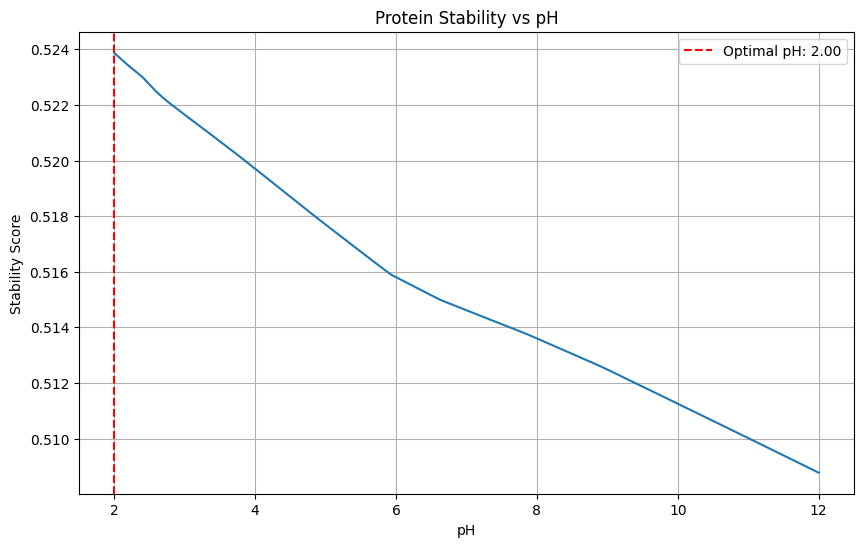

In [36]:
# Visualize stability across pH range
import matplotlib.pyplot as plt

pH_values = np.linspace(2, 12, 100)
plt.figure(figsize=(10, 6))
plt.plot(pH_values, stability_scores)
plt.xlabel('pH')
plt.ylabel('Stability Score')
plt.title('Protein Stability vs pH')
plt.axvline(x=optimal_pH, color='r', linestyle='--', label=f'Optimal pH: {optimal_pH:.2f}')
plt.legend()
plt.grid(True)
plt.show()

# Generate structure at optimal pH
ph_model.eval()
with torch.no_grad():
    optimal_structure = ph_model(
        test_protein['residue_features'].to(ph_trainer.device),
        test_protein['coords'].to(ph_trainer.device),
        torch.tensor([optimal_pH], device=ph_trainer.device)
    )
    
    # You can now use the contact map and other outputs to reconstruct 
    # the 3D structure at the optimal pH

## Training

In [39]:
# Train for pH optimization
num_epochs = 200
for epoch in range(num_epochs):
    loss = ph_trainer.train_epoch(ph_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")

Epoch 1/200, Loss: 0.1702
Epoch 2/200, Loss: 0.1703
Epoch 3/200, Loss: 0.1702
Epoch 4/200, Loss: 0.1702
Epoch 5/200, Loss: 0.1702
Epoch 6/200, Loss: 0.1702
Epoch 7/200, Loss: 0.1702
Epoch 8/200, Loss: 0.1702
Epoch 9/200, Loss: 0.1702
Epoch 10/200, Loss: 0.1702
Epoch 11/200, Loss: 0.1702
Epoch 12/200, Loss: 0.1702
Epoch 13/200, Loss: 0.1702
Epoch 14/200, Loss: 0.1702
Epoch 15/200, Loss: 0.1702
Epoch 16/200, Loss: 0.1702
Epoch 17/200, Loss: 0.1702
Epoch 18/200, Loss: 0.1702
Epoch 19/200, Loss: 0.1702
Epoch 20/200, Loss: 0.1702
Epoch 21/200, Loss: 0.1702
Epoch 22/200, Loss: 0.1702
Epoch 23/200, Loss: 0.1702
Epoch 24/200, Loss: 0.1702
Epoch 25/200, Loss: 0.1702
Epoch 26/200, Loss: 0.1702
Epoch 27/200, Loss: 0.1702
Epoch 28/200, Loss: 0.1702
Epoch 29/200, Loss: 0.1702
Epoch 30/200, Loss: 0.1702
Epoch 31/200, Loss: 0.1702
Epoch 32/200, Loss: 0.1702
Epoch 33/200, Loss: 0.1702
Epoch 34/200, Loss: 0.1702
Epoch 35/200, Loss: 0.1702
Epoch 36/200, Loss: 0.1702
Epoch 37/200, Loss: 0.1702
Epoch 38/2

In [40]:
# Find optimal pH for a protein
test_protein = ph_dataset[0]
optimal_pH, stability_scores = ph_trainer.find_optimal_pH(ph_model, test_protein)
print(f"Optimal pH: {optimal_pH:.2f}")

Optimal pH: 2.00


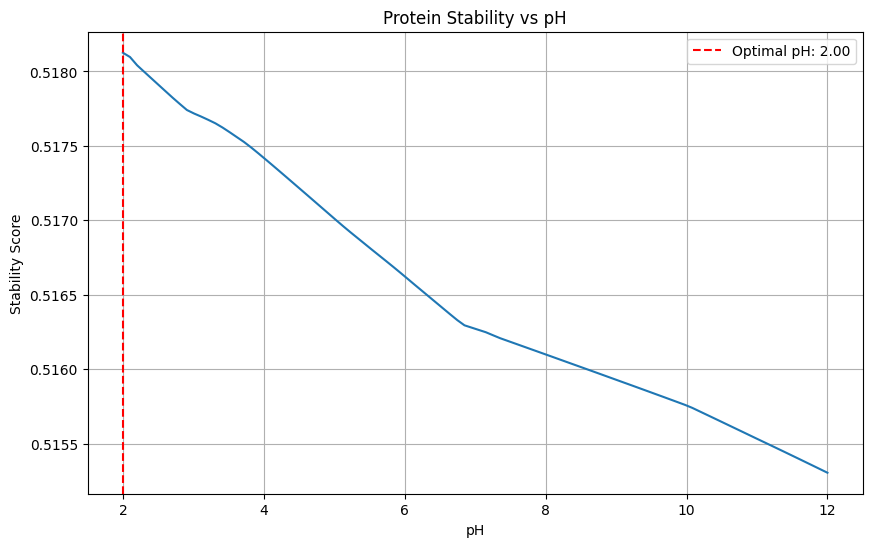

In [41]:
# Visualize stability across pH range
import matplotlib.pyplot as plt

pH_values = np.linspace(2, 12, 100)
plt.figure(figsize=(10, 6))
plt.plot(pH_values, stability_scores)
plt.xlabel('pH')
plt.ylabel('Stability Score')
plt.title('Protein Stability vs pH')
plt.axvline(x=optimal_pH, color='r', linestyle='--', label=f'Optimal pH: {optimal_pH:.2f}')
plt.legend()
plt.grid(True)
plt.show()

# Generate structure at optimal pH
ph_model.eval()
with torch.no_grad():
    optimal_structure = ph_model(
        test_protein['residue_features'].to(ph_trainer.device),
        test_protein['coords'].to(ph_trainer.device),
        torch.tensor([optimal_pH], device=ph_trainer.device)
    )
    
    # You can now use the contact map and other outputs to reconstruct 
    # the 3D structure at the optimal pH

# Protein reconstruction

In [50]:
import numpy as np
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform

class StructureReconstructor:
    def __init__(self):
        pass
    
    def reconstruct_from_contact_map(self, contact_map, initial_coords=None, 
                                   num_iterations=30, learning_rate=0.01):   # old value num iterations= 5000
        """Reconstruct 3D coordinates from a contact map"""
        n_residues = contact_map.shape[0]
        
        # Initialize coordinates randomly if not provided
        if initial_coords is None:
            coords = np.random.randn(n_residues, 3) * 10
        else:
            coords = initial_coords.copy()
        
        # Convert contact map to distance constraints
        # Convert probabilities to distances (lower probability = larger distance)
        distance_matrix = 1.0 / (contact_map + 1e-6)  # Avoid division by zero
        
        # Optimization using gradient descent
        for iteration in range(num_iterations):
            # Calculate current distances
            current_distances = squareform(pdist(coords))
            
            # Calculate gradient
            gradient = np.zeros_like(coords)
            for i in range(n_residues):
                for j in range(n_residues):
                    if i != j:
                        # Direction vector
                        direction = coords[i] - coords[j]
                        current_dist = np.linalg.norm(direction)
                        
                        # Target distance from contact map
                        target_dist = distance_matrix[i, j]
                        
                        # Force proportional to distance error
                        force = (current_dist - target_dist) / current_dist
                        gradient[i] -= force * direction
            
            # Update coordinates
            coords -= learning_rate * gradient
            
            # Optional: apply constraints (e.g., maintain bond lengths)
            coords = self.apply_constraints(coords)
            
            if iteration % 500 == 0:
                loss = np.mean((current_distances - distance_matrix) ** 2)
                print(f"Iteration {iteration}, Loss: {loss:.4f}")
        
        return coords
    
    def apply_constraints(self, coords):
        """Apply physical constraints to the coordinates"""
        # Ensure consecutive residues are at proper bond length
        bond_length = 3.8  # Typical CA-CA distance in Angstroms
        
        for i in range(len(coords) - 1):
            direction = coords[i+1] - coords[i]
            current_length = np.linalg.norm(direction)
            if current_length > 0:
                coords[i+1] = coords[i] + direction * (bond_length / current_length)
        
        return coords
    
    def reconstruct_with_multiple_contact_maps(self, contact_maps, distance_ranges):
        """Reconstruct using multiple contact maps at different distance ranges"""
        n_residues = contact_maps[0].shape[0]
        coords = np.random.randn(n_residues, 3) * 10
        
        def objective(flat_coords):
            coords = flat_coords.reshape(-1, 3)
            current_distances = squareform(pdist(coords))
            
            total_loss = 0
            for i, (contact_map, (lower, upper)) in enumerate(zip(contact_maps, distance_ranges)):
                # Create mask for this distance range
                mask = (current_distances >= lower) & (current_distances < upper)
                
                # Compare with contact map
                loss = np.sum((mask.astype(float) - contact_map) ** 2)
                total_loss += loss
            
            return total_loss
        
        # Optimize
        result = minimize(objective, coords.flatten(), method='L-BFGS-B',
                         options={'maxiter': 1000, 'disp': True})
        
        return result.x.reshape(-1, 3)

In [51]:
# Use the reconstruction with your pH model
# Generate structure at optimal pH
ph_model.eval()
with torch.no_grad():
    optimal_outputs = ph_model(
        test_protein['residue_features'].to(ph_trainer.device),
        test_protein['coords'].to(ph_trainer.device),
        torch.tensor([optimal_pH], device=ph_trainer.device)
    )
    
    # Get the contact map at optimal pH
    optimal_contact_map = optimal_outputs['contact_map'].cpu().numpy()
    
    # Reconstruct 3D structure
    reconstructor = StructureReconstructor()
    reconstructed_coords = reconstructor.reconstruct_from_contact_map(
        optimal_contact_map,
        initial_coords=test_protein['coords'].numpy()  # Use original coords as starting point
    )

Iteration 0, Loss: 258.7962


In [48]:
# Visualize the reconstruction
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_structure_comparison(original_coords, reconstructed_coords, title="Structure Comparison"):
    fig = plt.figure(figsize=(15, 7))
    
    # Original structure
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(original_coords[:, 0], original_coords[:, 1], original_coords[:, 2], 
             'b-', linewidth=2, alpha=0.8)
    ax1.scatter(original_coords[:, 0], original_coords[:, 1], original_coords[:, 2], 
                c='blue', s=20)
    ax1.set_title('Original Structure')
    
    # Reconstructed structure
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot(reconstructed_coords[:, 0], reconstructed_coords[:, 1], reconstructed_coords[:, 2], 
             'r-', linewidth=2, alpha=0.8)
    ax2.scatter(reconstructed_coords[:, 0], reconstructed_coords[:, 1], reconstructed_coords[:, 2], 
                c='red', s=20)
    ax2.set_title(f'Reconstructed at pH {optimal_pH:.2f}')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

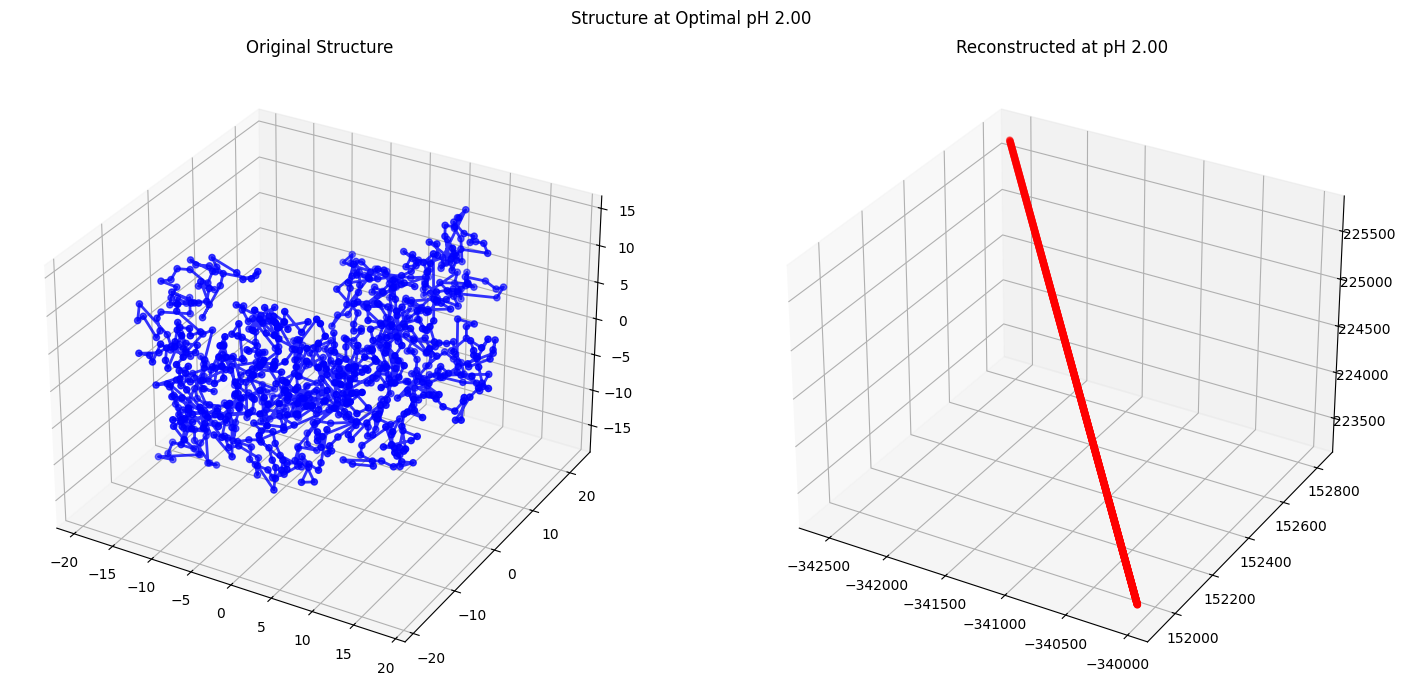

In [52]:
# Visualize the comparison
visualize_structure_comparison(
    test_protein['coords'].numpy(),
    reconstructed_coords,
    f"Structure at Optimal pH {optimal_pH:.2f}"
)

In [ ]:
# Save the reconstructed structure as a PDB file
def save_as_pdb(coords, residue_names, filename):
    with open(filename, 'w') as f:
        for i, (coord, res_name) in enumerate(zip(coords, residue_names)):
            atom_line = f"ATOM  {i+1:5d}  CA  {res_name:3s} A{i+1:4d}    " + \
                       f"{coord[0]:8.3f}{coord[1]:8.3f}{coord[2]:8.3f}" + \
                       f"  1.00  0.00           C  \n"
            f.write(atom_line)
        f.write("END\n")

# Save the reconstructed structure
save_as_pdb(
    reconstructed_coords,
    test_protein['res_names'],
    f"reconstructed_pH_{optimal_pH:.1f}.pdb"
)



In [ ]:
# If you have multiple contact maps at different distance ranges
if 'contact_maps' in test_protein:
    # Use multiple contact maps for better reconstruction
    contact_maps = []
    distance_ranges = []
    
    for config in CONFIGS:
        key = f"{config['lower']}-{config['upper']}"
        if key in test_protein['contact_maps']:
            contact_maps.append(test_protein['contact_maps'][key].numpy())
            distance_ranges.append((config['lower'], config['upper']))
    
    if contact_maps:
        multi_reconstructed_coords = reconstructor.reconstruct_with_multiple_contact_maps(
            contact_maps, distance_ranges
        )
        
        # Visualize this reconstruction too
        visualize_structure_comparison(
            test_protein['coords'].numpy(),
            multi_reconstructed_coords,
            "Multi-Contact Map Reconstruction"
        )

## Protein reconstruction, less computationally intense

In [53]:
class EfficientStructureReconstructor:
    def __init__(self):
        pass
    
    def fast_reconstruction(self, contact_map, num_residues=None):
        """Faster reconstruction using dimensionality reduction"""
        if num_residues is None:
            num_residues = contact_map.shape[0]
        
        # Convert contact map to distance matrix
        distance_matrix = 1.0 / (contact_map + 1e-6)
        
        # Use Multi-Dimensional Scaling (MDS) for fast approximation
        from sklearn.manifold import MDS
        
        mds = MDS(n_components=3, dissimilarity='precomputed', 
                  n_init=1, max_iter=300, n_jobs=-1)
        coords = mds.fit_transform(distance_matrix)
        
        # Quick constraint application
        coords = self.apply_fast_constraints(coords)
        
        return coords
    
    def apply_fast_constraints(self, coords):
        """Faster constraint application"""
        # Just normalize consecutive distances to approximate bond length
        bond_length = 3.8
        for i in range(len(coords) - 1):
            direction = coords[i+1] - coords[i]
            current_length = np.linalg.norm(direction)
            if current_length > 0:
                coords[i+1] = coords[i] + direction * (bond_length / current_length)
        return coords
    
    def batch_reconstruction(self, contact_maps, batch_size=10):
        """Process multiple proteins in batches"""
        results = []
        for i in range(0, len(contact_maps), batch_size):
            batch = contact_maps[i:i+batch_size]
            batch_results = [self.fast_reconstruction(cm) for cm in batch]
            results.extend(batch_results)
        return results

In [54]:
# Alternative: Use the model itself for reconstruction
class StructurePredictor(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)  # Output 3D coordinates
        )
    
    def forward(self, hidden_states):
        return self.decoder(hidden_states)

# Extend the pH model to directly predict coordinates
class pHAwareModelWithStructure(pHAwareModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.structure_predictor = StructurePredictor(self.hidden_dim)
    
    def forward(self, residue_features, coords, pH_value):
        outputs = super().forward(residue_features, coords, pH_value)
        
        # Get hidden states from attention
        h = self.residue_encoder(residue_features)
        ph_embedding = self.ph_encoder(pH_value.unsqueeze(-1))
        ph_expanded = ph_embedding.expand(h.size(0), h.size(1), -1)
        h_ph = self.ph_residue_fusion(torch.cat([h, ph_expanded], dim=-1))
        h_attended, _ = self.attention(h_ph, h_ph, h_ph)
        
        # Predict coordinates directly
        predicted_coords = self.structure_predictor(h_attended.squeeze(0))
        
        outputs['predicted_coords'] = predicted_coords
        return outputs

In [55]:
# Fix the quick_structure_at_pH function to ensure correct dtype
def quick_structure_at_pH(model, protein_data, target_pH, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """Get structure at specific pH quickly"""
    model.eval()
    with torch.no_grad():
        # Move model to device if not already there
        model = model.to(device)
        
        # Make sure target_pH is float32
        if isinstance(target_pH, (int, float)):
            pH_tensor = torch.tensor([target_pH], device=device, dtype=torch.float32)
        else:
            pH_tensor = target_pH.float()  # Convert to float32 if it's already a tensor
        
        outputs = model(
            protein_data['residue_features'].to(device),
            protein_data['coords'].to(device),
            pH_tensor
        )
        
        if 'predicted_coords' in outputs:
            return outputs['predicted_coords'].cpu().numpy()
        else:
            # Fallback to fast reconstruction
            contact_map = outputs['contact_map'].cpu().numpy()
            reconstructor = EfficientStructureReconstructor()
            return reconstructor.fast_reconstruction(contact_map)

In [56]:
# Fix the structure predictor class
class StructurePredictor(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3)  # Output 3D coordinates
        )
    
    def forward(self, hidden_states):
        return self.decoder(hidden_states)

# Fix the pH-aware model with structure prediction
class pHAwareModelWithStructure(pHAwareModel):
    def __init__(self, input_dim=20, hidden_dim=128, num_heads=8):
        super().__init__(input_dim, hidden_dim, num_heads)
        self.hidden_dim = hidden_dim  # Store hidden_dim as an attribute
        self.structure_predictor = StructurePredictor(hidden_dim)
    
    def forward(self, residue_features, coords, pH_value):
        outputs = super().forward(residue_features, coords, pH_value)
        
        # Ensure inputs have batch dimension
        if residue_features.dim() == 2:
            residue_features = residue_features.unsqueeze(0)
        if isinstance(pH_value, float):
            pH_value = torch.tensor([pH_value], device=residue_features.device)
        if pH_value.dim() == 0:
            pH_value = pH_value.unsqueeze(0)
        
        # Get hidden states from attention
        h = self.residue_encoder(residue_features)
        ph_embedding = self.ph_encoder(pH_value.unsqueeze(-1))
        ph_expanded = ph_embedding.expand(h.size(0), h.size(1), -1)
        h_ph = self.ph_residue_fusion(torch.cat([h, ph_expanded], dim=-1))
        h_attended, _ = self.attention(h_ph, h_ph, h_ph)
        
        # Remove batch dimension if needed
        if h_attended.size(0) == 1:
            h_attended = h_attended.squeeze(0)
        
        # Predict coordinates directly
        predicted_coords = self.structure_predictor(h_attended)
        
        outputs['predicted_coords'] = predicted_coords
        return outputs



In [57]:
# Now create and train the model
ph_model_with_structure = pHAwareModelWithStructure()
ph_trainer = pHOptimizationTrainer(ph_model_with_structure, ph_dataset)

In [58]:
# Train for some epochs
num_epochs = 2
for epoch in range(num_epochs):
    loss = ph_trainer.train_epoch(ph_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")


Epoch 1/2, Loss: 0.2629
Epoch 2/2, Loss: 0.2483


In [59]:
# Find optimal pH
test_protein = ph_dataset[0]
optimal_pH, stability_scores = ph_trainer.find_optimal_pH(ph_model_with_structure, test_protein)
print(f"Optimal pH: {optimal_pH:.2f}")

Optimal pH: 2.00


In [60]:
# Get structure at optimal pH
predicted_coords_optimal = quick_structure_at_pH(ph_model_with_structure, test_protein, optimal_pH)

In [61]:
# Get structures at different pH values for comparison
pH_values = [4.0, 7.0, optimal_pH, 10.0]
structures_at_different_pH = {}

for pH in pH_values:
    structures_at_different_pH[pH] = quick_structure_at_pH(ph_model_with_structure, test_protein, pH)

In [62]:
def visualize_pH_structures(original_coords, pH_structures, stability_scores=None):
    """Visualize structures at different pH values"""
    n_structures = len(pH_structures) + 1
    cols = 3
    rows = (n_structures + cols - 1) // cols
    
    fig = plt.figure(figsize=(6*cols, 5*rows))
    
    # Plot original structure
    ax = fig.add_subplot(rows, cols, 1, projection='3d')
    ax.plot(original_coords[:, 0], original_coords[:, 1], original_coords[:, 2], 
            'b-', linewidth=2, alpha=0.8)
    ax.scatter(original_coords[:, 0], original_coords[:, 1], original_coords[:, 2], 
               c='blue', s=20)
    ax.set_title('Original Structure')
    
    # Plot structures at different pH values
    for idx, (pH, coords) in enumerate(pH_structures.items(), 2):
        ax = fig.add_subplot(rows, cols, idx, projection='3d')
        
        # Color based on whether it's the optimal pH
        color = 'red' if pH == optimal_pH else 'green'
        
        # Fix the plot format string
        ax.plot(coords[:, 0], coords[:, 1], coords[:, 2], 
                color=color, linestyle='-', linewidth=2, alpha=0.8)
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
                   c=color, s=20)
        
        title = f'pH {pH:.1f}'
        if pH == optimal_pH:
            title += ' (Optimal)'
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()
    
    # Plot stability curve if provided
    if stability_scores is not None:
        plt.figure(figsize=(10, 6))
        pH_range = np.linspace(2, 12, len(stability_scores))
        plt.plot(pH_range, stability_scores, 'b-', linewidth=2)
        plt.xlabel('pH', fontsize=14)
        plt.ylabel('Stability Score', fontsize=14)
        plt.title('Protein Stability vs pH', fontsize=16)
        plt.axvline(x=optimal_pH, color='r', linestyle='--', 
                   label=f'Optimal pH: {optimal_pH:.2f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

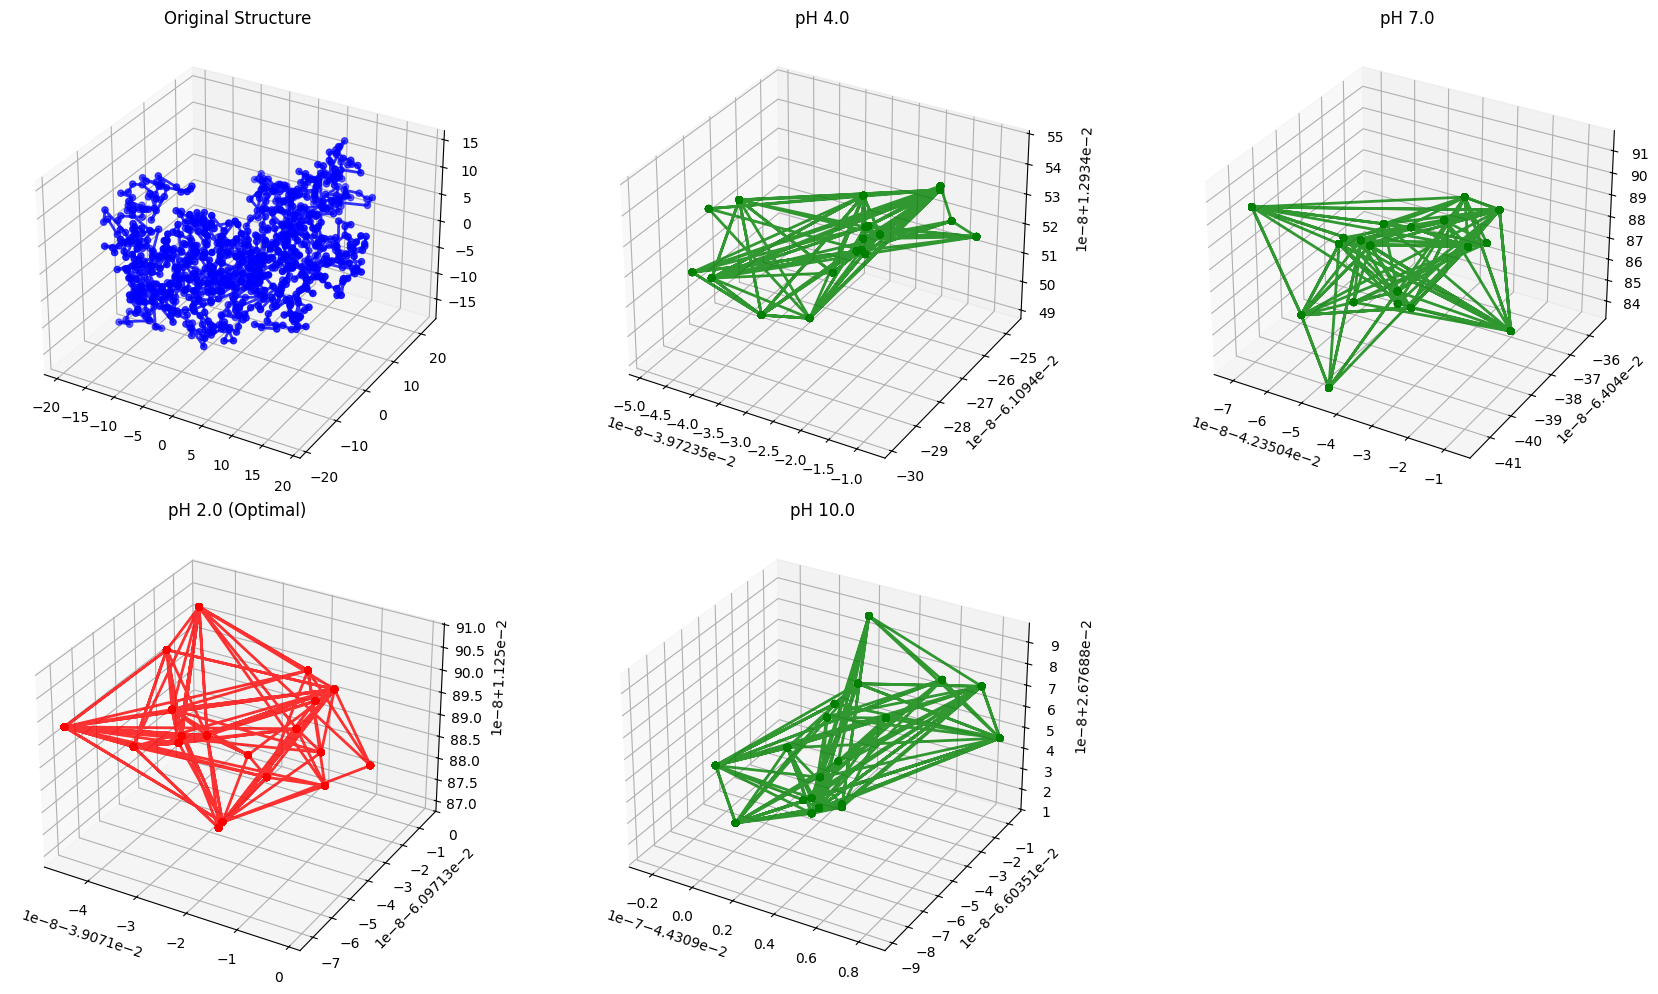

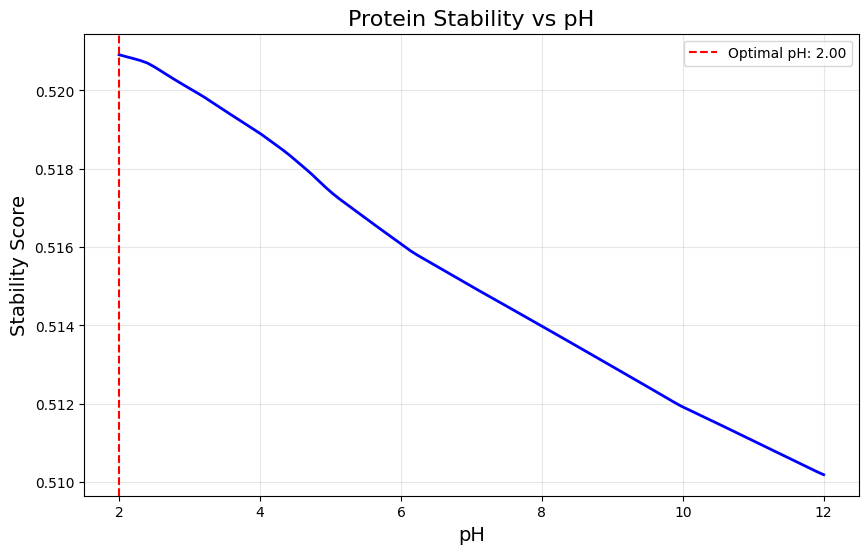

In [63]:
# Visualize the structures
visualize_pH_structures(
    test_protein['coords'].numpy(),
    structures_at_different_pH,
    stability_scores
)


# Visualizations, enhanced

In [64]:
import matplotlib.cm as cm

def visualize_pH_structures_beautiful(original_coords, pH_structures, residue_info, stability_scores=None):
    """Enhanced visualization of structures at different pH values with rainbow coloring"""
    n_structures = len(pH_structures) + 1
    cols = 3
    rows = (n_structures + cols - 1) // cols
    
    # Create color map based on residue position (rainbow from N to C terminus)
    num_residues = len(original_coords)
    colors = cm.rainbow(np.linspace(0, 1, num_residues))
    
    fig = plt.figure(figsize=(8*cols, 6*rows))
    
    # Function to plot a single structure with rainbow coloring
    def plot_structure_rainbow(ax, coords, title):
        # Plot backbone with colored segments
        for i in range(len(coords) - 1):
            ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2],
                   color=colors[i], linewidth=2, alpha=0.8)
        
        # Plot CA atoms with rainbow colors
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                  c=colors, s=40, alpha=0.9, edgecolors='black', linewidth=0.5)
        
        # Style the plot
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        
        # Remove background and make more aesthetic
        ax.grid(False)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('lightgray')
        ax.yaxis.pane.set_edgecolor('lightgray')
        ax.zaxis.pane.set_edgecolor('lightgray')
        
        # Adjust viewing angle for better visualization
        ax.view_init(elev=20, azim=45)
    
    # Plot original structure
    ax = fig.add_subplot(rows, cols, 1, projection='3d')
    plot_structure_rainbow(ax, original_coords, 'Original Structure')
    
    # Plot structures at different pH values
    for idx, (pH, coords) in enumerate(pH_structures.items(), 2):
        ax = fig.add_subplot(rows, cols, idx, projection='3d')
        
        title = f'pH {pH:.1f}'
        if pH == optimal_pH:
            title += ' (Optimal)'
            # Add subtle highlight for optimal pH
            ax.set_facecolor('#f0f0ff')
        
        plot_structure_rainbow(ax, coords, title)
    
    plt.tight_layout()
    plt.show()
    
    # Enhanced stability curve
    if stability_scores is not None:
        fig, ax = plt.subplots(figsize=(12, 8))
        pH_range = np.linspace(2, 12, len(stability_scores))
        
        # Create gradient background
        gradient = np.linspace(0, 1, 100).reshape(1, -1)
        ax.imshow(gradient, aspect='auto', cmap='coolwarm', 
                  extent=[2, 12, min(stability_scores)*0.9, max(stability_scores)*1.1], 
                  alpha=0.1)
        
        # Plot stability curve with enhanced styling
        ax.plot(pH_range, stability_scores, 'b-', linewidth=3, alpha=0.8)
        ax.fill_between(pH_range, stability_scores, alpha=0.3)
        
        # Mark optimal pH with enhanced styling
        ax.axvline(x=optimal_pH, color='red', linestyle='--', linewidth=2,
                  label=f'Optimal pH: {optimal_pH:.2f}')
        ax.scatter(optimal_pH, stability_scores[np.argmin(np.abs(pH_range - optimal_pH))],
                  color='red', s=100, zorder=5, edgecolor='white', linewidth=2)
        
        # Enhanced styling
        ax.set_xlabel('pH', fontsize=16, fontweight='bold')
        ax.set_ylabel('Stability Score', fontsize=16, fontweight='bold')
        ax.set_title('Protein Stability vs pH', fontsize=20, fontweight='bold', pad=20)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()

In [65]:
# Alternative version with amino acid type coloring
def visualize_pH_structures_by_aa_type(original_coords, pH_structures, residue_names, stability_scores=None):
    """Visualization with colors based on amino acid type"""
    n_structures = len(pH_structures) + 1
    cols = 3
    rows = (n_structures + cols - 1) // cols
    
    # Define color scheme for amino acid types
    aa_colors = {
        # Hydrophobic
        'ALA': '#FFCCCC', 'VAL': '#FFCCCC', 'ILE': '#FFCCCC', 
        'LEU': '#FFCCCC', 'MET': '#FFCCCC', 'PHE': '#FFCCCC', 
        'TRP': '#FFCCCC', 'PRO': '#FFCCCC',
        # Polar
        'SER': '#CCFFCC', 'THR': '#CCFFCC', 'CYS': '#CCFFCC', 
        'ASN': '#CCFFCC', 'GLN': '#CCFFCC', 'TYR': '#CCFFCC',
        # Charged positive
        'LYS': '#CCCCFF', 'ARG': '#CCCCFF', 'HIS': '#CCCCFF',
        # Charged negative
        'ASP': '#FFFF99', 'GLU': '#FFFF99',
        # Special
        'GLY': '#DDDDDD'
    }
    
    # Get colors for each residue
    residue_colors = [aa_colors.get(res, '#999999') for res in residue_names]
    
    fig = plt.figure(figsize=(8*cols, 6*rows))
    
    def plot_structure_aa_type(ax, coords, title):
        # Plot backbone
        ax.plot(coords[:, 0], coords[:, 1], coords[:, 2],
               'gray', linewidth=1, alpha=0.5)
        
        # Plot CA atoms colored by amino acid type
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                  c=residue_colors, s=60, alpha=0.9, 
                  edgecolors='black', linewidth=0.5)
        
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.grid(False)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.view_init(elev=20, azim=45)
    
    # Plot all structures
    ax = fig.add_subplot(rows, cols, 1, projection='3d')
    plot_structure_aa_type(ax, original_coords, 'Original Structure')
    
    for idx, (pH, coords) in enumerate(pH_structures.items(), 2):
        ax = fig.add_subplot(rows, cols, idx, projection='3d')
        title = f'pH {pH:.1f}'
        if pH == optimal_pH:
            title += ' (Optimal)'
        plot_structure_aa_type(ax, coords, title)
    
    # Add legend for amino acid types
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FFCCCC', edgecolor='black', label='Hydrophobic'),
        Patch(facecolor='#CCFFCC', edgecolor='black', label='Polar'),
        Patch(facecolor='#CCCCFF', edgecolor='black', label='Positive'),
        Patch(facecolor='#FFFF99', edgecolor='black', label='Negative'),
        Patch(facecolor='#DDDDDD', edgecolor='black', label='Glycine')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, 
               bbox_to_anchor=(0.5, 0.98), fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Stability curve (same as before but enhanced)
    if stability_scores is not None:
        # Use the enhanced stability curve from the previous function
        pass



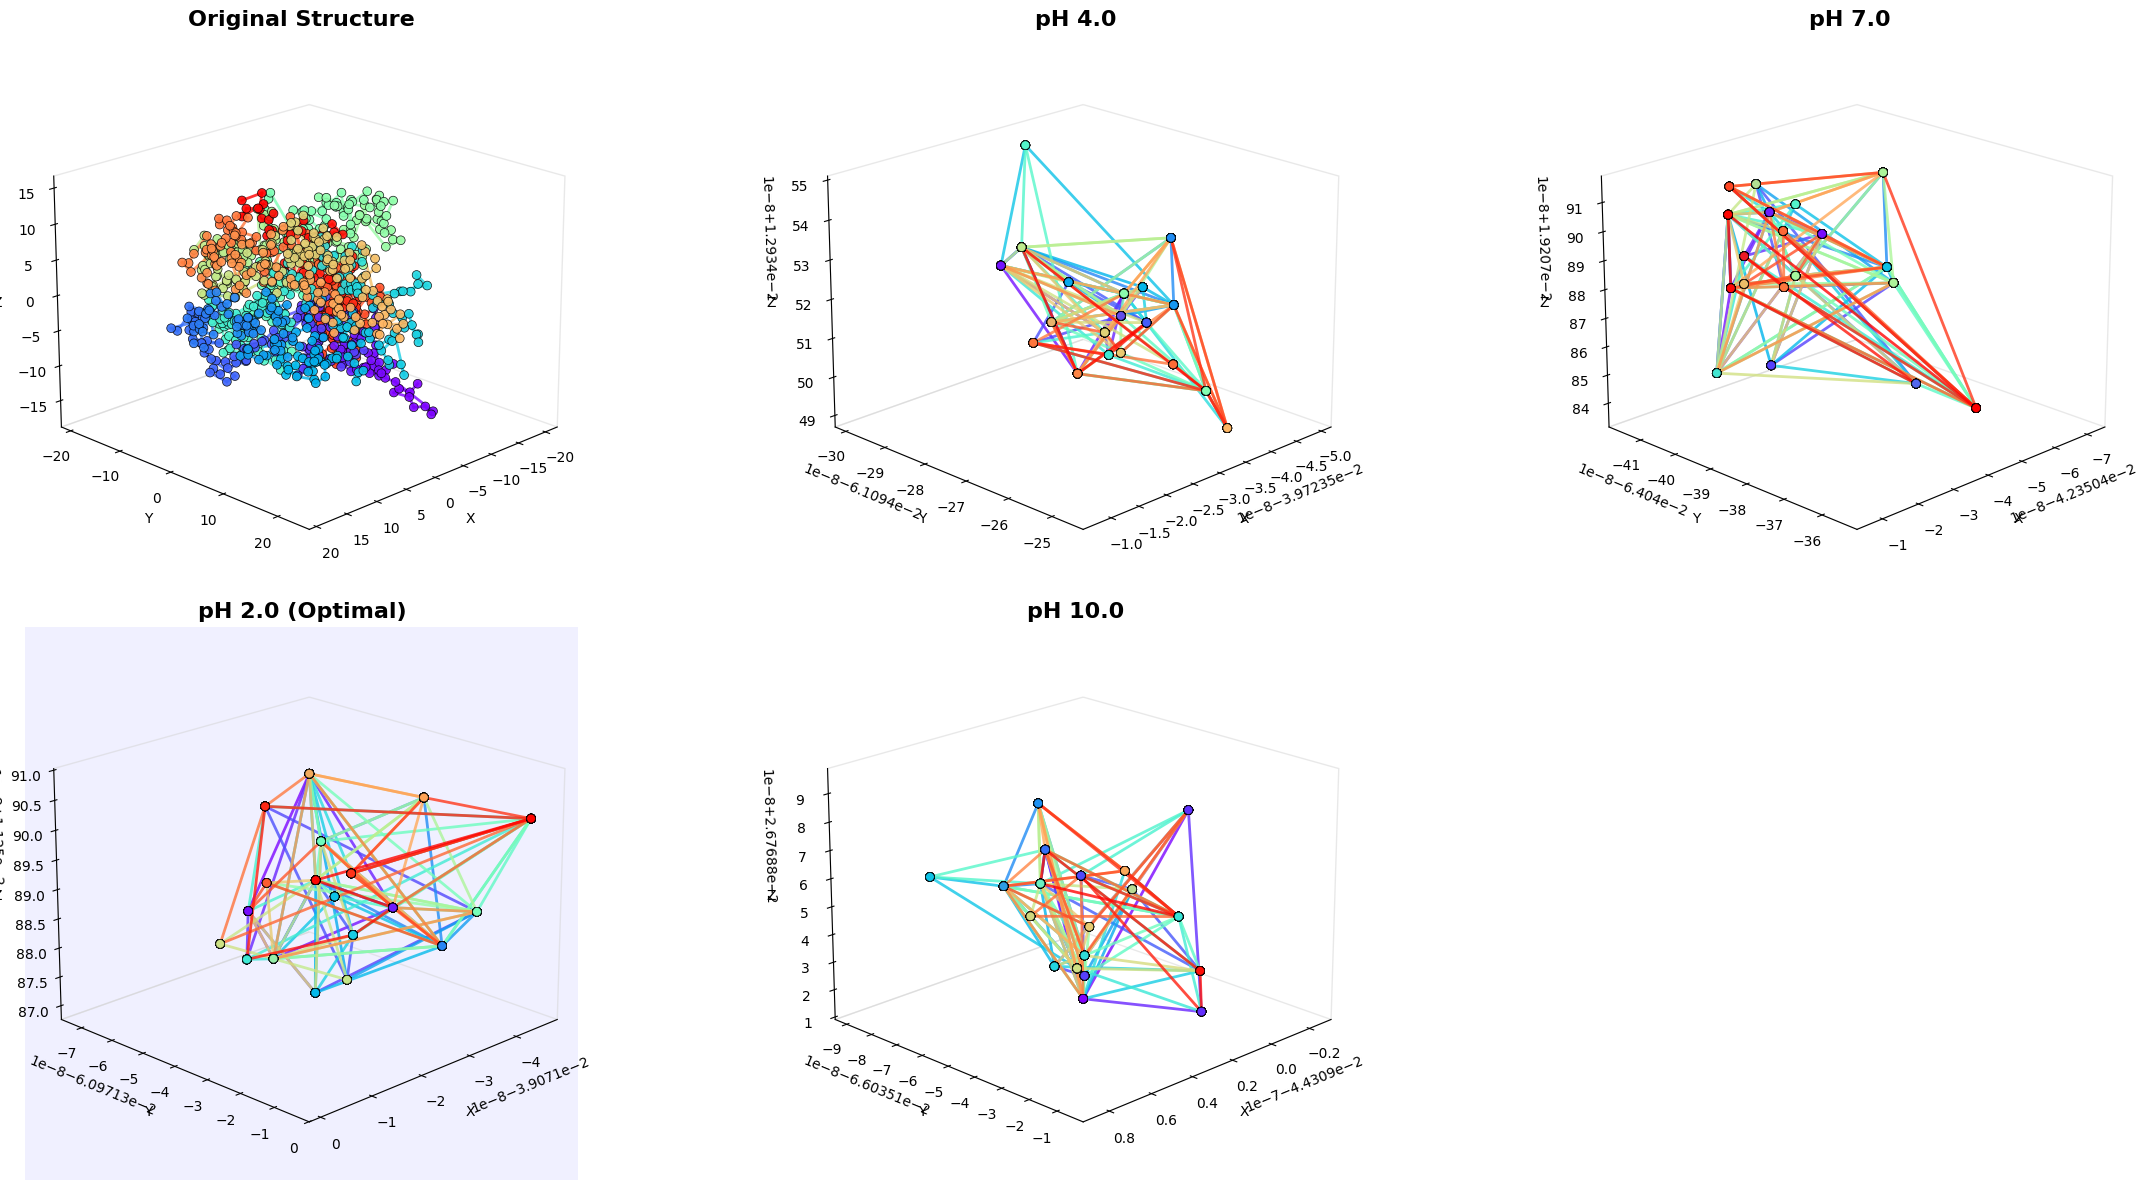

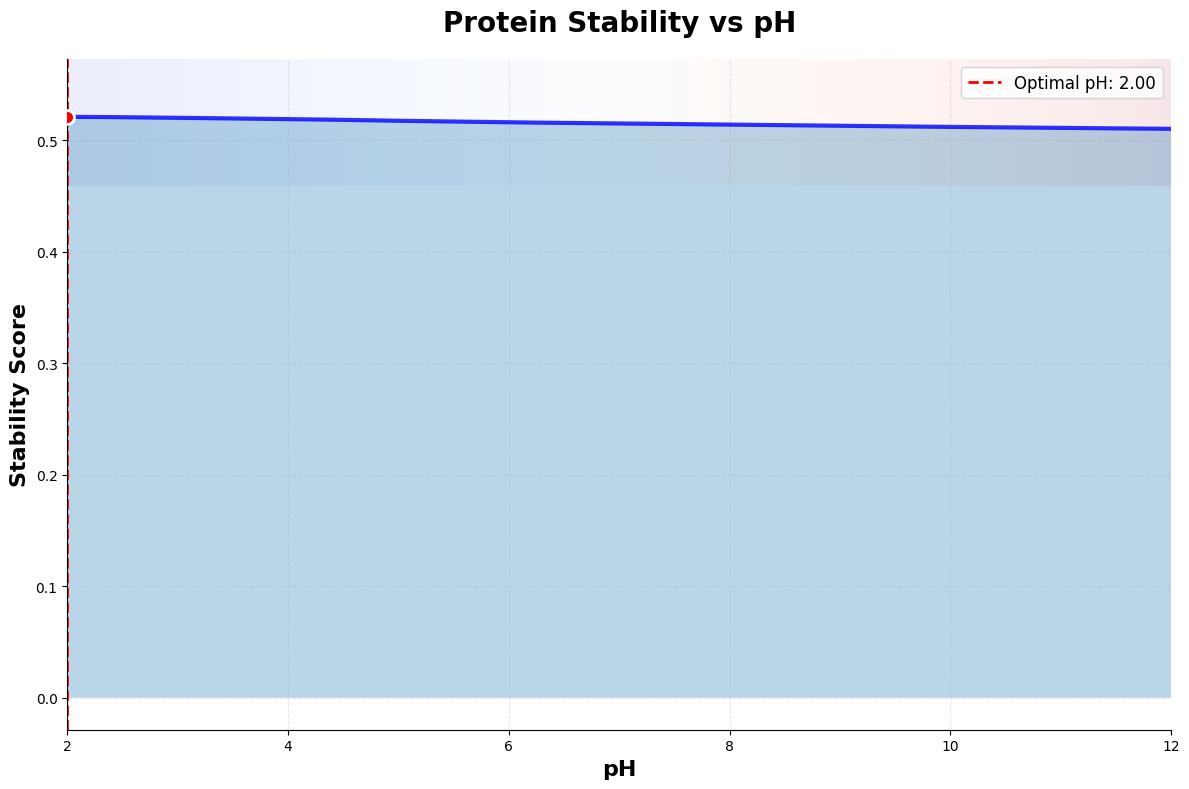

In [66]:
# Use the functions
visualize_pH_structures_beautiful(
    test_protein['coords'].numpy(),
    structures_at_different_pH,
    test_protein['res_names'],
    stability_scores
)

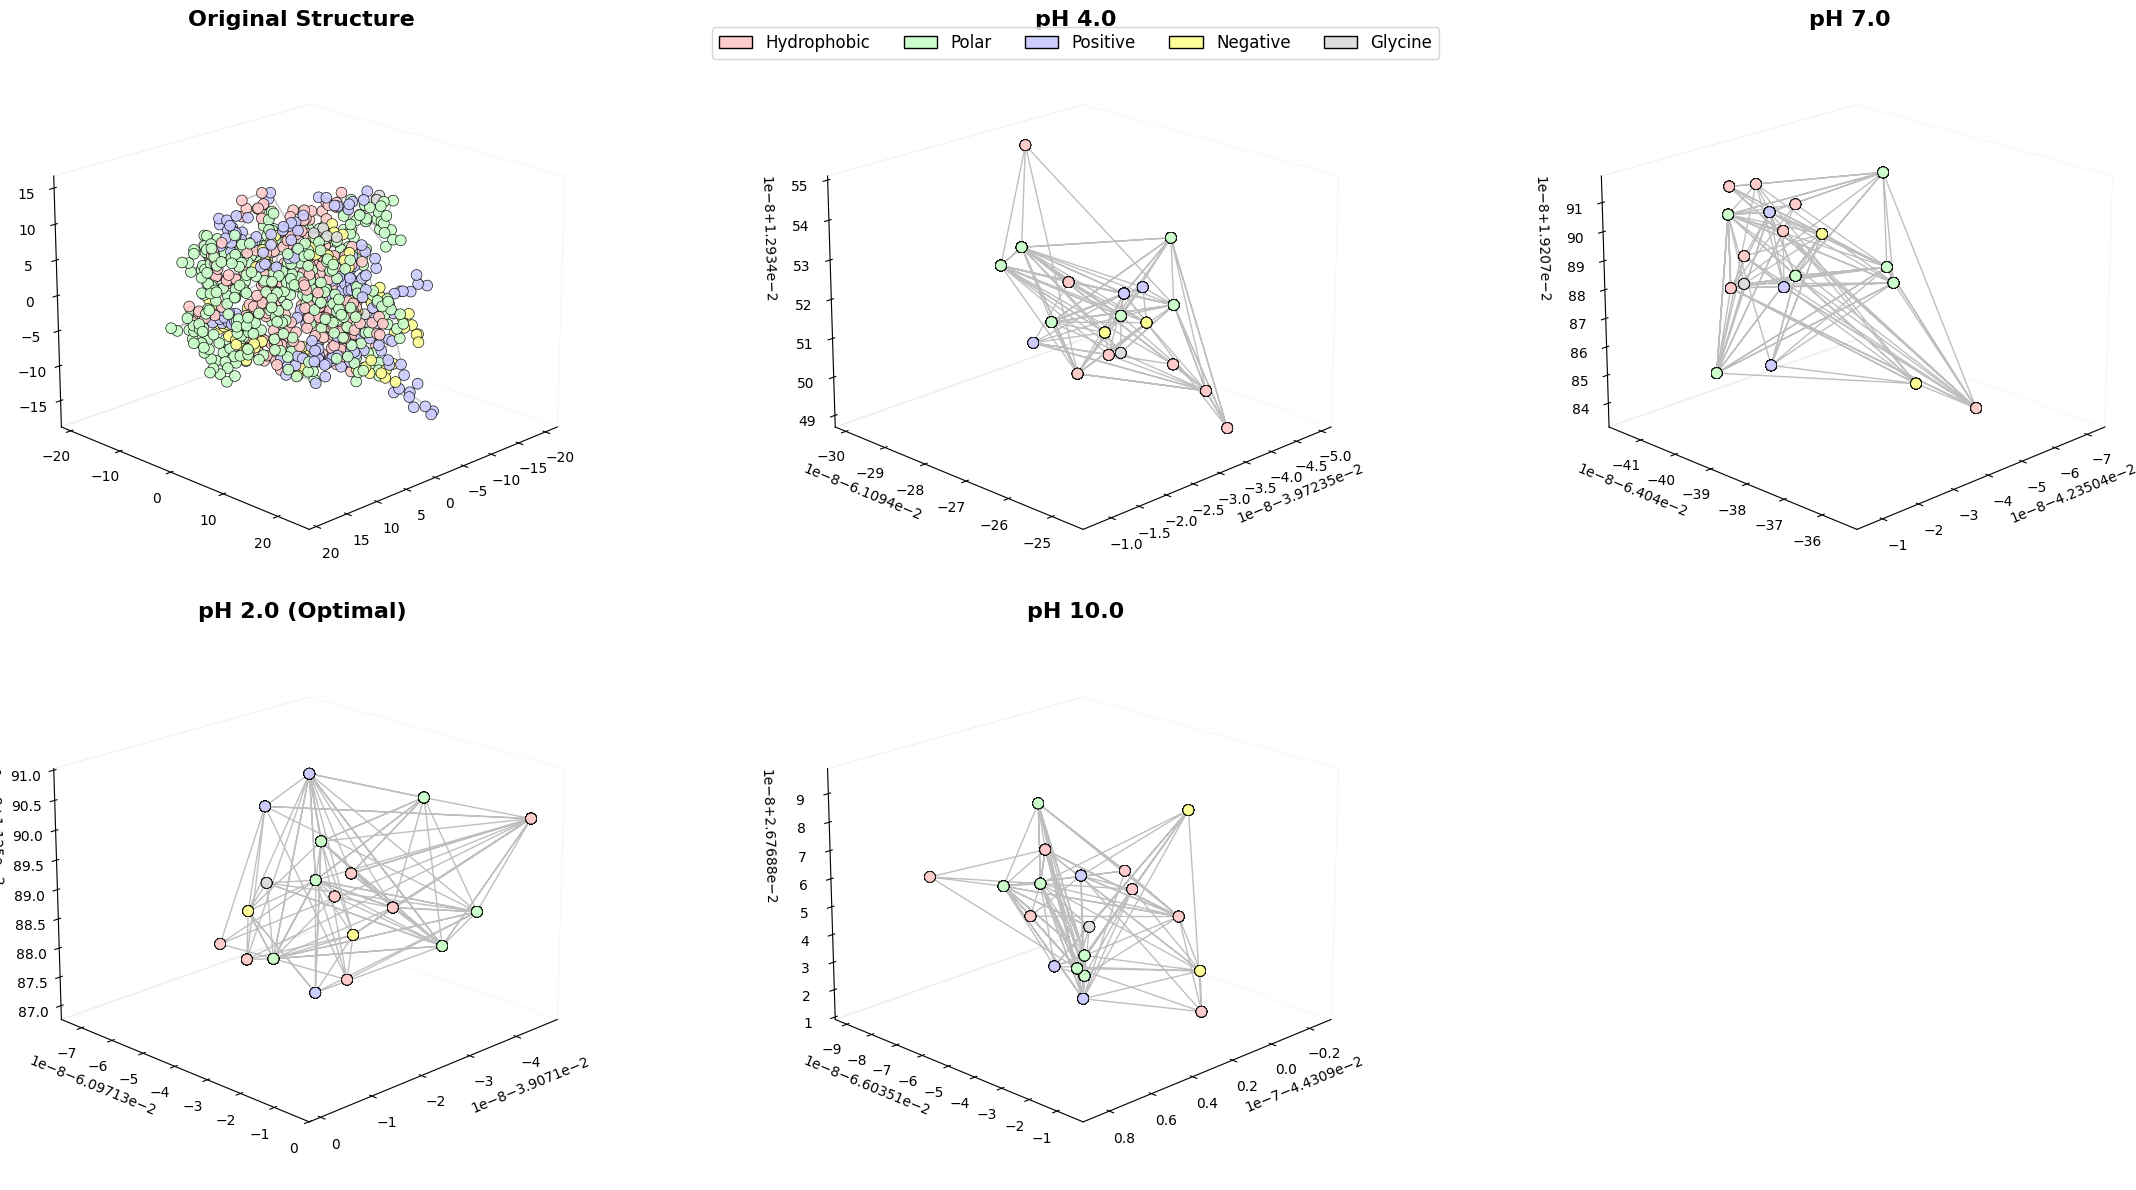

In [67]:
# Or use the amino acid type coloring
visualize_pH_structures_by_aa_type(
    test_protein['coords'].numpy(),
    structures_at_different_pH,
    test_protein['res_names'],
    stability_scores
)

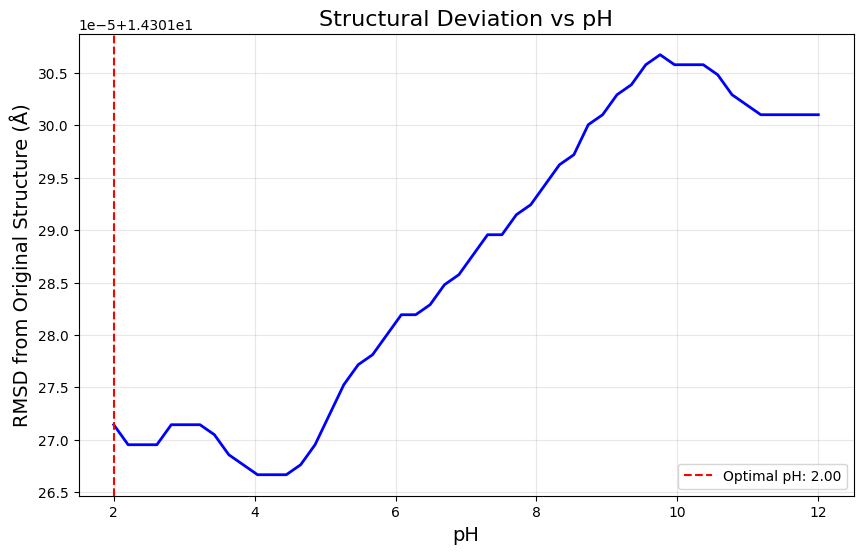

In [68]:
# Compare RMSD across pH values
def calculate_rmsd(coords1, coords2):
    """Calculate Root Mean Square Deviation between two sets of coordinates"""
    return np.sqrt(np.mean(np.sum((coords1 - coords2)**2, axis=1)))

# Plot RMSD vs pH
rmsd_values = []
pH_range = np.linspace(2, 12, 50)

for pH in pH_range:
    coords = quick_structure_at_pH(ph_model_with_structure, test_protein, pH)
    rmsd = calculate_rmsd(test_protein['coords'].numpy(), coords)
    rmsd_values.append(rmsd)

plt.figure(figsize=(10, 6))
plt.plot(pH_range, rmsd_values, 'b-', linewidth=2)
plt.xlabel('pH', fontsize=14)
plt.ylabel('RMSD from Original Structure (Å)', fontsize=14)
plt.title('Structural Deviation vs pH', fontsize=16)
plt.axvline(x=optimal_pH, color='r', linestyle='--', 
           label=f'Optimal pH: {optimal_pH:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
# Interactive visualization using plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def interactive_pH_visualization(original_coords, pH_structures):
    """Create interactive 3D visualization with plotly"""
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}],
               [{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        subplot_titles=[f'pH {pH:.1f}' for pH in pH_structures.keys()]
    )
    
    for idx, (pH, coords) in enumerate(pH_structures.items(), 1):
        row = (idx - 1) // 2 + 1
        col = (idx - 1) % 2 + 1
        
        fig.add_trace(
            go.Scatter3d(
                x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
                mode='lines+markers',
                line=dict(width=3, color='blue'),
                marker=dict(size=3, color='red'),
                name=f'pH {pH:.1f}'
            ),
            row=row, col=col
        )
    
    fig.update_layout(height=800, width=1000, title_text="Protein Structure at Different pH Values")
    fig.show()

# Create interactive visualization
interactive_pH_visualization(test_protein['coords'].numpy(), structures_at_different_pH)

# Full protein approach

In [83]:
class pHOptimizationTrainer:
    def __init__(self, model, dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        # Amino acid pKa values for ground truth
        self.pKa_values = {
            'ASP': 3.9, 'GLU': 4.3, 'HIS': 6.0, 
            'CYS': 8.3, 'TYR': 10.1, 'LYS': 10.5, 
            'ARG': 12.5
        }
    
    def calculate_theoretical_charge(self, residue_name, pH):
        """Calculate theoretical charge based on Henderson-Hasselbalch equation"""
        if residue_name not in self.pKa_values:
            return 0.0
        
        pKa = self.pKa_values[residue_name]
        
        if residue_name in ['ASP', 'GLU', 'CYS', 'TYR']:  # Acidic
            charge = -1 / (1 + 10**(pKa - pH))
        else:  # Basic (HIS, LYS, ARG)
            charge = 1 / (1 + 10**(pH - pKa))
        
        return charge
    
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        
        for batch in dataloader:
            self.optimizer.zero_grad()
            
            # Move to device and ensure float32
            residue_features = batch['residue_features'].float().to(self.device)
            coords = batch['coords'].float().to(self.device)
            
            # Handle contact maps depending on its format
            if 'contact_maps' in batch and isinstance(batch['contact_maps'], (torch.Tensor, list)):
                # If it's a tensor or list, take first element
                contact_maps = batch['contact_maps'][0].float().to(self.device) if batch['contact_maps'].size(0) > 0 else None
            elif 'contact_maps' in batch and isinstance(batch['contact_maps'], dict):
                # If it's a dictionary of contact maps
                contact_maps = {}
                for key, cmap in batch['contact_maps'].items():
                    if isinstance(cmap, torch.Tensor):
                        contact_maps[key] = cmap.float().to(self.device)
                    else:
                        contact_maps[key] = torch.tensor(cmap, dtype=torch.float32).to(self.device)
            else:
                # Fallback if no contact maps
                contact_maps = None
            
            # Sample random pH values for training
            pH_values = torch.rand(5, device=self.device, dtype=torch.float32) * 10 + 2  # pH 2-12
            
            batch_loss = 0
            for pH in pH_values:
                # Forward pass
                outputs = self.model(residue_features, coords, pH)
                
                # Contact map loss (if available)
                contact_loss = 0
                if contact_maps is not None and 'contact_map' in outputs:
                    # Choose the appropriate contact map or use the first one
                    if isinstance(contact_maps, dict) and len(contact_maps) > 0:
                        first_key = list(contact_maps.keys())[0]
                        contact_loss = F.mse_loss(outputs['contact_map'], contact_maps[first_key])
                    elif isinstance(contact_maps, torch.Tensor):
                        contact_loss = F.mse_loss(outputs['contact_map'], contact_maps)
                
                # Charge loss
                residue_names = batch['res_names']
                theoretical_charges = []
                for res_name in residue_names:
                    charge = self.calculate_theoretical_charge(res_name, pH.item())
                    theoretical_charges.append(charge)
                theoretical_charges = torch.tensor(theoretical_charges, device=self.device, dtype=torch.float32).unsqueeze(-1)
                charge_loss = F.mse_loss(outputs['charges'], theoretical_charges)
                
                # Combined loss
                loss = contact_loss + 0.5 * charge_loss
                batch_loss += loss
            
            # Average loss over pH values
            batch_loss /= len(pH_values)
            
            # Backward pass
            batch_loss.backward()
            self.optimizer.step()
            
            total_loss += batch_loss.item()
        
        return total_loss / len(dataloader)

    
    def find_optimal_pH(self, model, protein_data, pH_range=(2, 12), num_samples=100):
        """Find the pH that maximizes stability"""
        model.eval()
        
        with torch.no_grad():
            residue_features = protein_data['residue_features'].to(self.device)
            coords = protein_data['coords'].to(self.device)
            
            pH_values = torch.linspace(pH_range[0], pH_range[1], num_samples, device=self.device)
            stability_scores = []
            
            for pH in pH_values:
                outputs = model(residue_features, coords, pH)
                stability_scores.append(outputs['stability'].item())
            
            optimal_idx = np.argmax(stability_scores)
            optimal_pH = pH_values[optimal_idx].item()
            
            return optimal_pH, stability_scores


In [84]:
class FullProteinReconstructor(pHAwareModelWithStructure):
    def __init__(self, input_dim=20, hidden_dim=128, num_heads=8, chunk_size=50):
        super().__init__(input_dim, hidden_dim, num_heads)
        self.chunk_size = chunk_size
        
    def forward_full_protein(self, residue_features, coords, pH_value):
        """Process full protein by chunks and reconstruct complete structure"""
        num_residues = residue_features.shape[0]
        num_chunks = (num_residues + self.chunk_size - 1) // self.chunk_size
        
        all_predicted_coords = []
        
        for i in range(num_chunks):
            start_idx = i * self.chunk_size
            end_idx = min(start_idx + self.chunk_size, num_residues)
            
            chunk_features = residue_features[start_idx:end_idx]
            chunk_coords = coords[start_idx:end_idx]
            
            # Process chunk
            outputs = self.forward(chunk_features, chunk_coords, pH_value)
            predicted_chunk = outputs['predicted_coords']
            
            # Align chunk to previous chunk if not the first one
            if i > 0 and len(all_predicted_coords) > 0:
                # Align using the overlapping residues
                overlap = 5  # Use 5 residues for alignment
                if start_idx >= overlap:
                    prev_end = all_predicted_coords[-1][-overlap:]
                    curr_start = predicted_chunk[:overlap]
                    
                    # Calculate transformation to align chunks
                    translation = prev_end.mean(dim=0) - curr_start.mean(dim=0)
                    predicted_chunk = predicted_chunk + translation
            
            all_predicted_coords.append(predicted_chunk)
        
        # Concatenate all chunks
        full_predicted_coords = torch.cat(all_predicted_coords, dim=0)
        
        # Apply global refinement
        full_predicted_coords = self.global_refinement(full_predicted_coords)
        
        return full_predicted_coords
    
    def global_refinement(self, coords):
        """Refine the full structure to ensure physical consistency"""
        # Ensure proper bond lengths between all consecutive residues
        for i in range(len(coords) - 1):
            direction = coords[i+1] - coords[i]
            current_length = torch.norm(direction)
            if current_length > 0:
                coords[i+1] = coords[i] + direction * (3.8 / current_length)
        
        return coords

In [85]:
# Function to reconstruct full protein at specific pH
def reconstruct_full_protein_at_pH(model, protein_data, target_pH, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """Reconstruct the complete protein structure at a given pH"""
    model.eval()
    with torch.no_grad():
        model = model.to(device)
        
        # Use the full protein data
        full_residue_features = protein_data['residue_features'].to(device)
        full_coords = protein_data['coords'].to(device)
        pH_tensor = torch.tensor([target_pH], device=device, dtype=torch.float32)
        
        # Reconstruct full protein
        if hasattr(model, 'forward_full_protein'):
            predicted_coords = model.forward_full_protein(full_residue_features, full_coords, pH_tensor)
        else:
            # Fallback to chunk-by-chunk reconstruction
            chunk_size = 50
            all_predicted_coords = []
            
            for i in range(0, len(full_coords), chunk_size):
                chunk_features = full_residue_features[i:i+chunk_size]
                chunk_coords = full_coords[i:i+chunk_size]
                
                outputs = model(chunk_features, chunk_coords, pH_tensor)
                predicted_chunk = outputs['predicted_coords']
                all_predicted_coords.append(predicted_chunk)
            
            predicted_coords = torch.cat(all_predicted_coords, dim=0)
        
        return predicted_coords.cpu().numpy()

In [86]:
# Create full protein dataset
class FullProteinDataset(Dataset):
    def __init__(self, enhanced_proteins):
        self.data = enhanced_proteins

    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        protein = self.data[idx]
        
        # Return full protein data without chunking
        coords = torch.FloatTensor(protein['coords'])
        residue_features = self.create_residue_features(protein)
        
        return {
            'coords': coords,
            'residue_features': residue_features,
            'res_names': protein['res_names'],
            'contact_maps': protein['contact_maps']
        }
    
    def create_residue_features(self, protein):
        """Create feature vector for each residue in the full protein"""
        aa_types = ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 
                   'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 
                   'TYR', 'VAL']
        
        features = []
        for res_name in protein['res_names']:
            one_hot = torch.zeros(len(aa_types))
            if res_name in aa_types:
                one_hot[aa_types.index(res_name)] = 1
            features.append(one_hot)
        
        return torch.stack(features)

In [87]:
# Train model for full protein reconstruction
full_protein_model = FullProteinReconstructor()
full_protein_dataset = FullProteinDataset(enhanced_proteins)
full_protein_dataloader = DataLoader(full_protein_dataset, batch_size=1, shuffle=True)

trainer = pHOptimizationTrainer(full_protein_model, full_protein_dataset)

In [88]:
# Train the model
num_epochs = 100
for epoch in range(num_epochs):
    loss = trainer.train_epoch(full_protein_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")



C:\Users\laran\AppData\Local\Temp\ipykernel_22048\3731776929.py:70: UserWarning:

Using a target size (torch.Size([1, 951, 951])) that is different to the input size (torch.Size([951, 951])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



Epoch 1/100, Loss: 0.2628
Epoch 2/100, Loss: 0.2355
Epoch 3/100, Loss: 0.2232
Epoch 4/100, Loss: 0.1993
Epoch 5/100, Loss: 0.1776
Epoch 6/100, Loss: 0.1834
Epoch 7/100, Loss: 0.2008
Epoch 8/100, Loss: 0.1889
Epoch 9/100, Loss: 0.2010
Epoch 10/100, Loss: 0.1938
Epoch 11/100, Loss: 0.1920
Epoch 12/100, Loss: 0.1885
Epoch 13/100, Loss: 0.1781
Epoch 14/100, Loss: 0.1818
Epoch 15/100, Loss: 0.1745
Epoch 16/100, Loss: 0.1785
Epoch 17/100, Loss: 0.1773
Epoch 18/100, Loss: 0.1839
Epoch 19/100, Loss: 0.1804
Epoch 20/100, Loss: 0.1803
Epoch 21/100, Loss: 0.1762
Epoch 22/100, Loss: 0.1711
Epoch 23/100, Loss: 0.1716
Epoch 24/100, Loss: 0.1751
Epoch 25/100, Loss: 0.1739
Epoch 26/100, Loss: 0.1736
Epoch 27/100, Loss: 0.1722
Epoch 28/100, Loss: 0.1752
Epoch 29/100, Loss: 0.1747
Epoch 30/100, Loss: 0.1717
Epoch 31/100, Loss: 0.1719
Epoch 32/100, Loss: 0.1730
Epoch 33/100, Loss: 0.1706
Epoch 34/100, Loss: 0.1742
Epoch 35/100, Loss: 0.1815
Epoch 36/100, Loss: 0.1717
Epoch 37/100, Loss: 0.1730
Epoch 38/1

In [89]:
# Reconstruct full protein at different pH values
test_protein = full_protein_dataset[0]
pH_values = [4.0, 7.0, optimal_pH, 10.0]
full_protein_structures = {}

for pH in pH_values:
    full_protein_structures[pH] = reconstruct_full_protein_at_pH(full_protein_model, test_protein, pH)



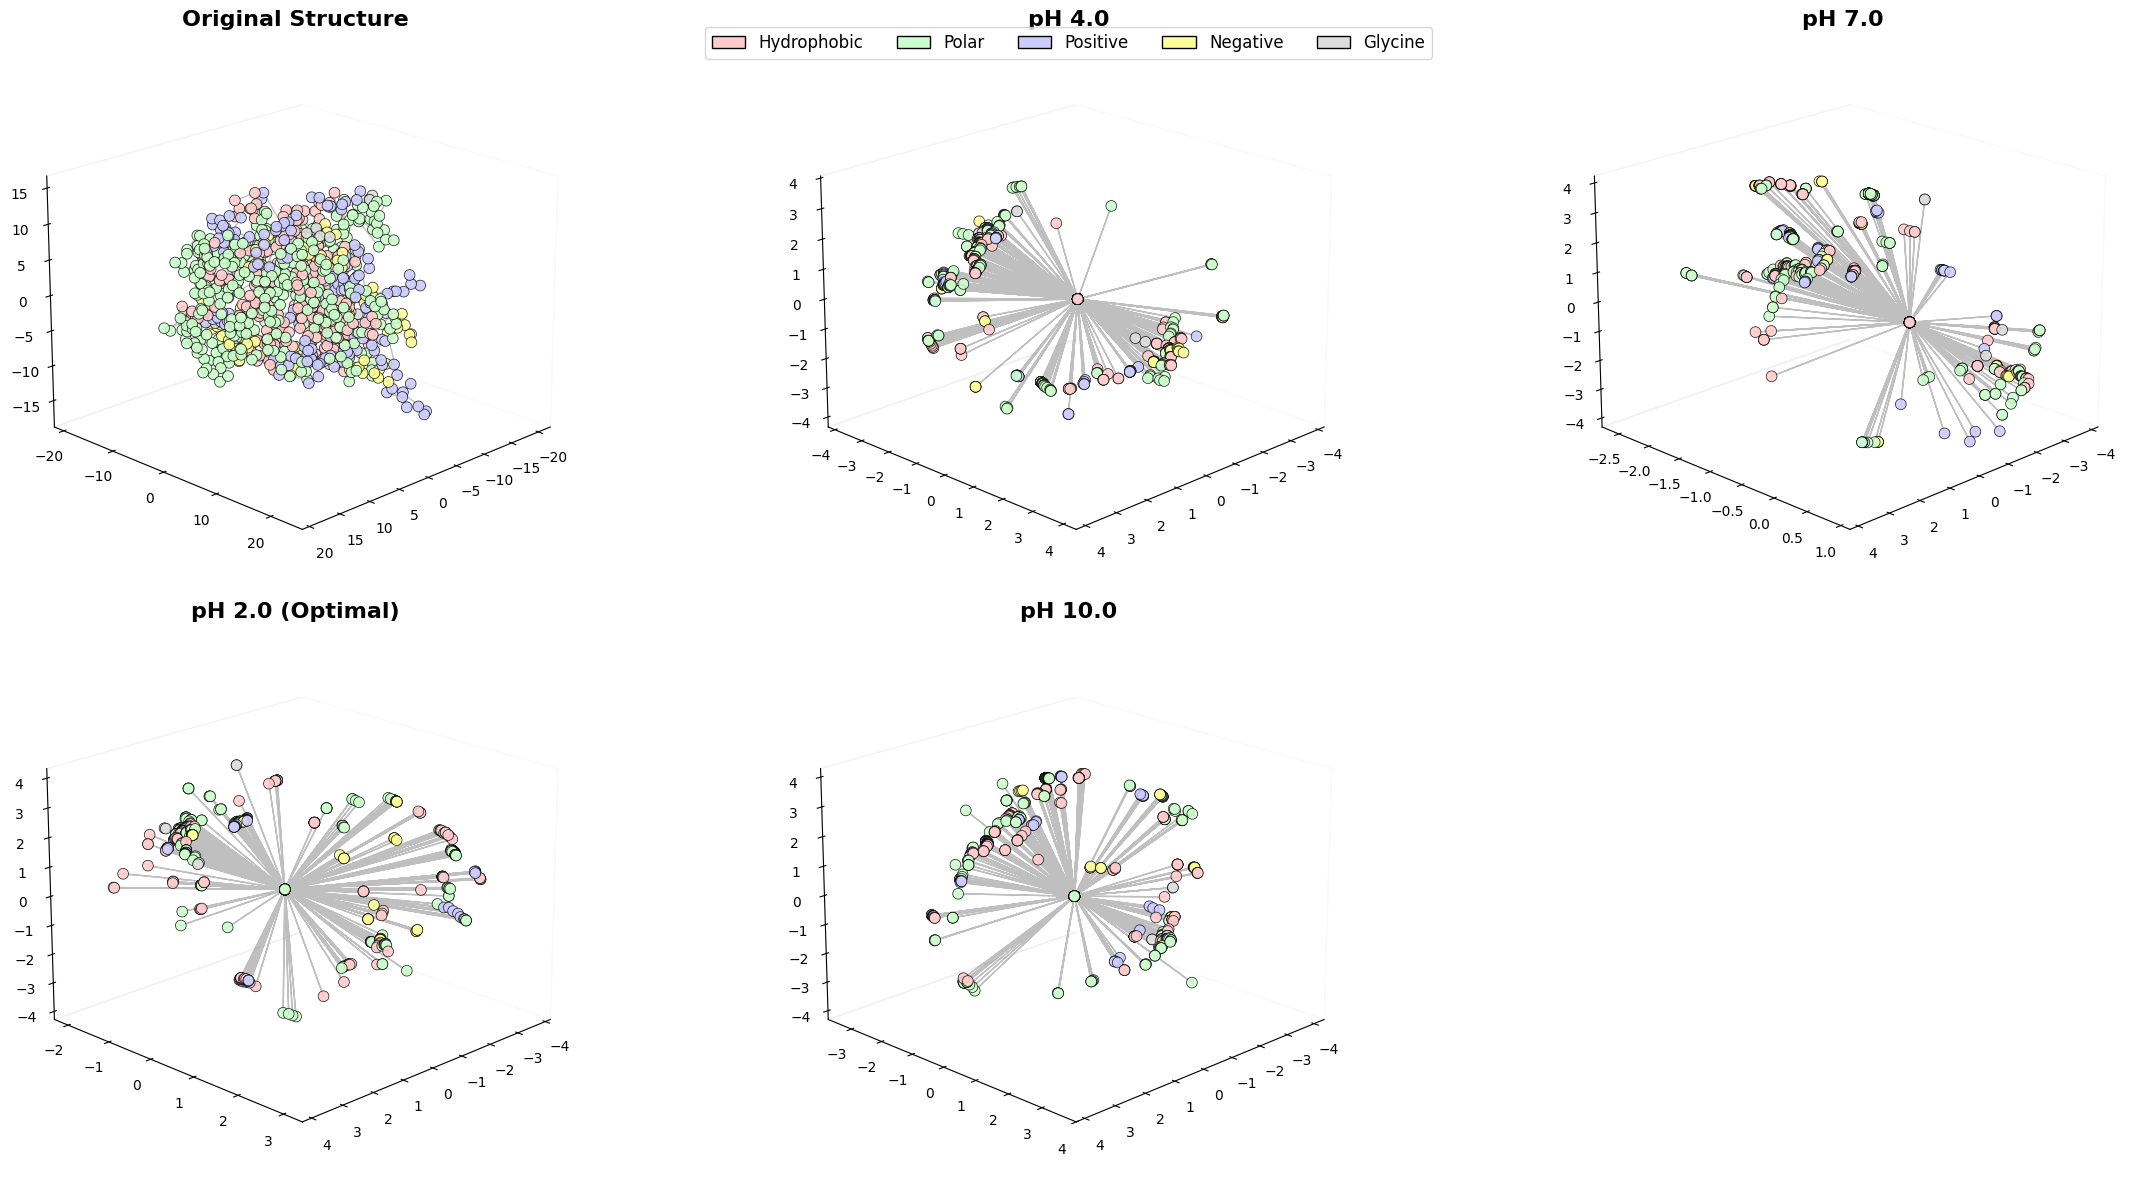

In [90]:
# Visualize full protein structures
visualize_pH_structures_by_aa_type(
    test_protein['coords'].numpy(),
    full_protein_structures,
    test_protein['res_names'],
    stability_scores
)

### refining the reconstruction 

In [93]:
def improve_protein_reconstruction(coords, original_coords=None, refinement_steps=1000):
    """Apply geometric constraints to improve protein structure"""
    import copy
    import numpy as np
    from scipy.spatial.distance import pdist, squareform
    
    # Make a copy to avoid modifying the original
    improved_coords = copy.deepcopy(coords)
    
    # Calculate distance matrix of original structure if provided
    if original_coords is not None:
        original_dist = squareform(pdist(original_coords))
    
    # Apply bond length constraints (CA-CA ~3.8Å)
    for _ in range(refinement_steps):
        # Apply bond length constraints
        for i in range(len(improved_coords) - 1):
            direction = improved_coords[i+1] - improved_coords[i]
            current_length = np.linalg.norm(direction)
            if current_length > 0:
                # Adjust to ideal CA-CA distance
                improved_coords[i+1] = improved_coords[i] + direction * (3.8 / current_length)
        
        # Apply global structure constraints if original is provided
        if original_coords is not None and len(improved_coords) > 3:
            # Calculate current distance matrix
            current_dist = squareform(pdist(improved_coords))
            
            # Apply distance constraint forces
            forces = np.zeros_like(improved_coords)
            for i in range(len(improved_coords)):
                for j in range(i+2, len(improved_coords)):  # Skip adjacent residues
                    # Direction vector
                    direction = improved_coords[j] - improved_coords[i]
                    current_dist_ij = np.linalg.norm(direction)
                    
                    if current_dist_ij > 0:
                        # Target distance from original structure
                        target_dist_ij = original_dist[i, j]
                        
                        # Calculate force based on distance difference
                        force_magnitude = (current_dist_ij - target_dist_ij) * 0.01
                        force = force_magnitude * direction / current_dist_ij
                        
                        # Apply force to both residues
                        forces[i] += force
                        forces[j] -= force
            
            # Update coordinates based on forces
            improved_coords += forces
    
    return improved_coords



In [97]:
# Refine all reconstructed structures
refined_structures = {}
for pH, coords in full_protein_structures.items():
    # Use original structure as reference for refinement
    refined_structures[pH] = improve_protein_reconstruction(
        coords, 
        original_coords=test_protein['coords'].numpy(),
        refinement_steps=100
    )

In [98]:
# Create an enhanced visualization function that matches the original structure scale
def visualize_matched_protein_structures(original_coords, pH_structures, residue_names, stability_scores=None):
    """Visualization that ensures all structures are on the same scale and orientation"""
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import numpy as np
    
    n_structures = len(pH_structures) + 1
    cols = 3
    rows = (n_structures + cols - 1) // cols
    
    # Define color scheme for amino acid types
    aa_colors = {
        # Hydrophobic
        'ALA': '#FFCCCC', 'VAL': '#FFCCCC', 'ILE': '#FFCCCC', 
        'LEU': '#FFCCCC', 'MET': '#FFCCCC', 'PHE': '#FFCCCC', 
        'TRP': '#FFCCCC', 'PRO': '#FFCCCC',
        # Polar
        'SER': '#CCFFCC', 'THR': '#CCFFCC', 'CYS': '#CCFFCC', 
        'ASN': '#CCFFCC', 'GLN': '#CCFFCC', 'TYR': '#CCFFCC',
        # Charged positive
        'LYS': '#CCCCFF', 'ARG': '#CCCCFF', 'HIS': '#CCCCFF',
        # Charged negative
        'ASP': '#FFFF99', 'GLU': '#FFFF99',
        # Special
        'GLY': '#DDDDDD'
    }
    
    # Get colors for each residue
    residue_colors = [aa_colors.get(res, '#999999') for res in residue_names]
    
    # Calculate global bounds to use for all plots
    all_coords = [original_coords]
    all_coords.extend([coords for _, coords in pH_structures.items()])
    all_coords_array = np.vstack(all_coords)
    
    # Find min/max for each dimension with some padding
    global_min = np.min(all_coords_array, axis=0) - 2
    global_max = np.max(all_coords_array, axis=0) + 2
    
    fig = plt.figure(figsize=(8*cols, 6*rows))
    
    def plot_structure(ax, coords, title):
        # Plot backbone
        for i in range(len(coords) - 1):
            ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2],
                   color='gray', linewidth=1, alpha=0.7)
        
        # Plot CA atoms colored by amino acid type
        scatter = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                  c=residue_colors, s=60, alpha=0.9, 
                  edgecolors='black', linewidth=0.5)
        
        # Set consistent axis limits
        ax.set_xlim(global_min[0], global_max[0])
        ax.set_ylim(global_min[1], global_max[1])
        ax.set_zlim(global_min[2], global_max[2])
        
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Better viewing angle
        ax.view_init(elev=30, azim=45)
    
    # Plot original structure
    ax = fig.add_subplot(rows, cols, 1, projection='3d')
    plot_structure(ax, original_coords, 'Original Structure')
    
    # Plot structures at different pH values
    for idx, (pH, coords) in enumerate(pH_structures.items(), 2):
        ax = fig.add_subplot(rows, cols, idx, projection='3d')
        
        title = f'pH {pH:.1f}'
        if pH == optimal_pH:
            title += ' (Optimal)'
        
        plot_structure(ax, coords, title)
    
    # Add legend for amino acid types
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FFCCCC', edgecolor='black', label='Hydrophobic'),
        Patch(facecolor='#CCFFCC', edgecolor='black', label='Polar'),
        Patch(facecolor='#CCCCFF', edgecolor='black', label='Positive'),
        Patch(facecolor='#FFFF99', edgecolor='black', label='Negative'),
        Patch(facecolor='#DDDDDD', edgecolor='black', label='Glycine')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, 
               bbox_to_anchor=(0.5, 0.98), fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # Make room for the legend
    plt.show()



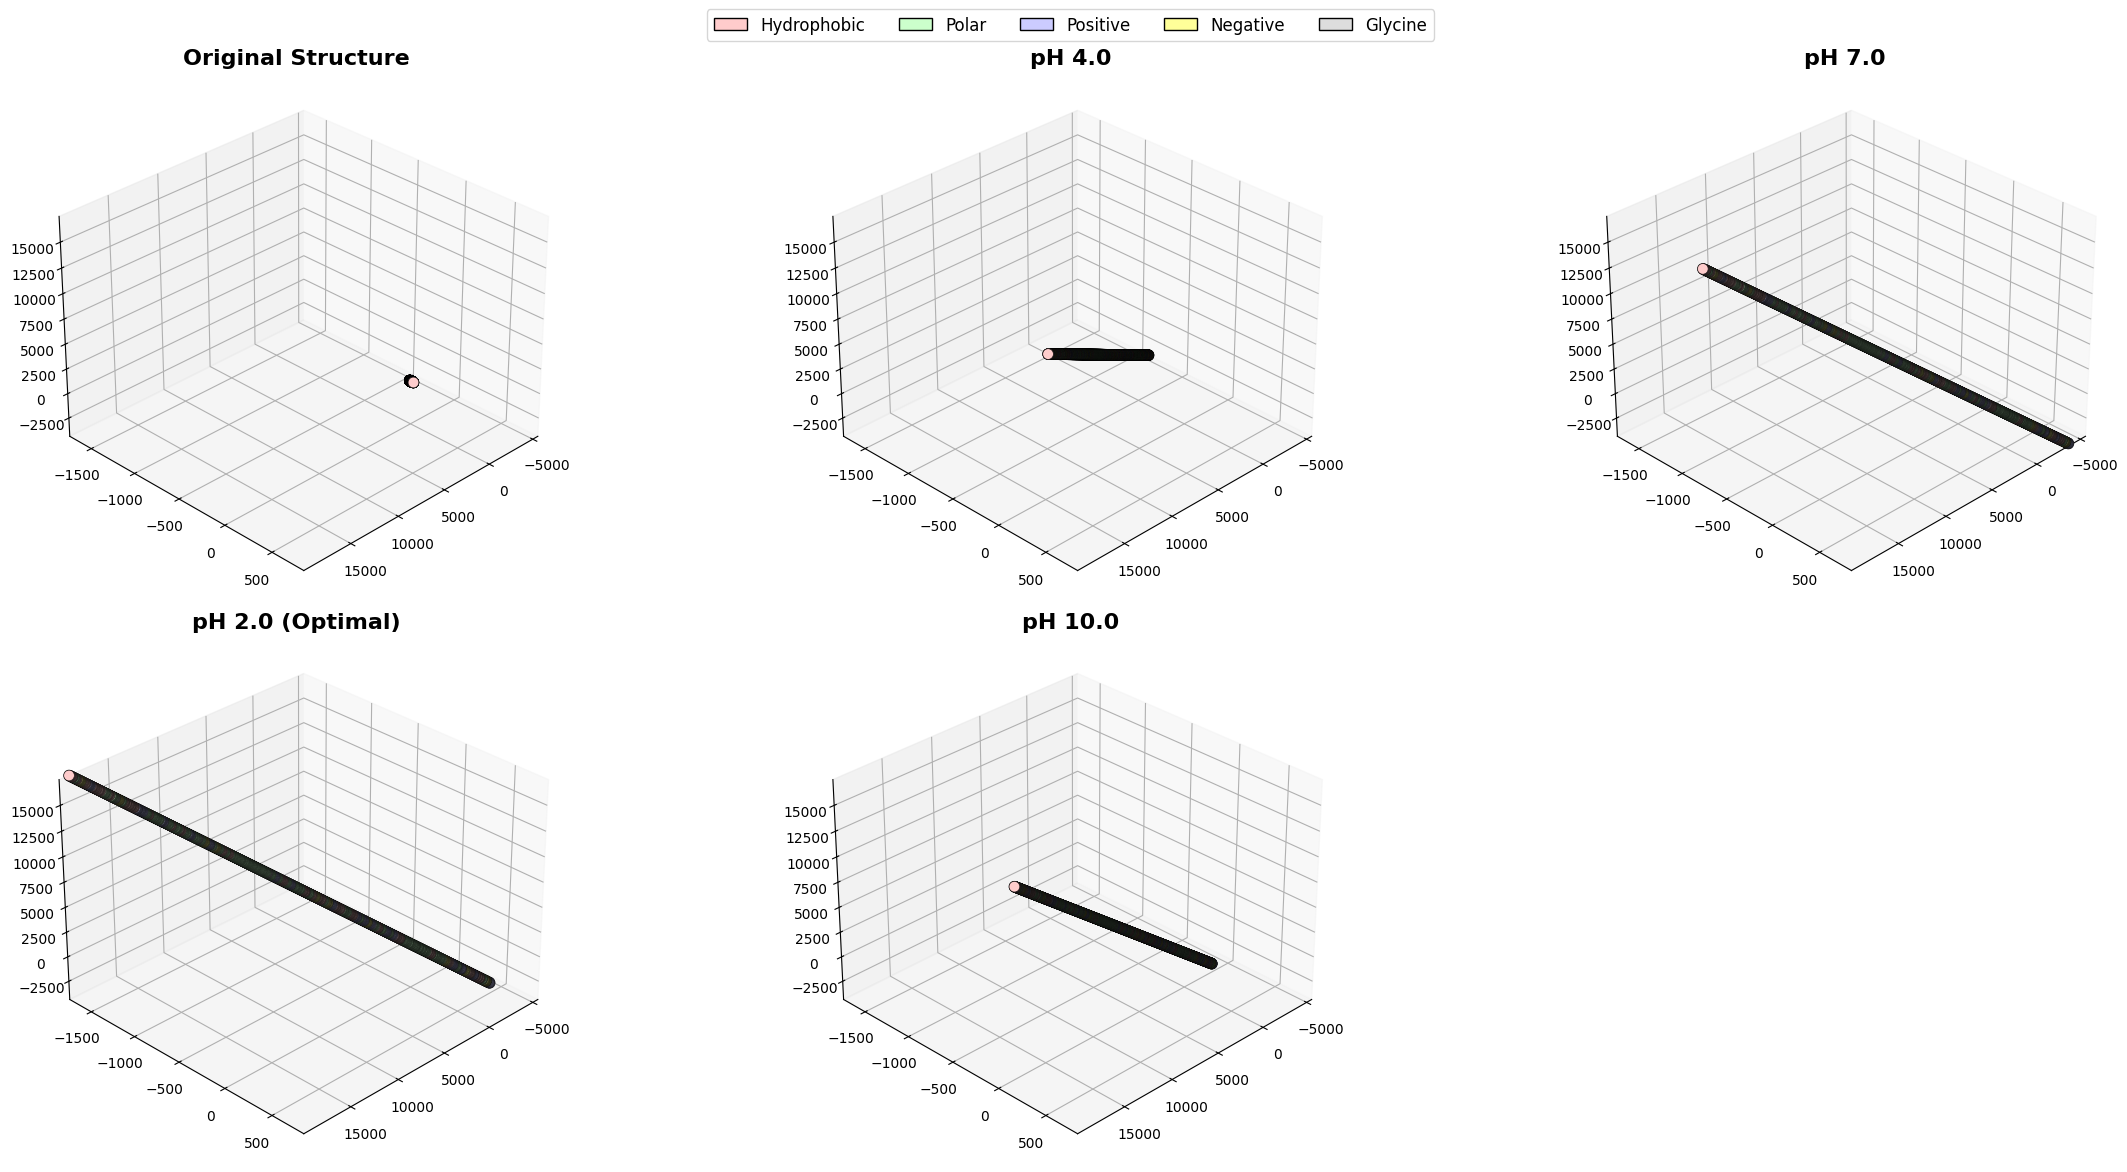

In [99]:
# Visualize the refined structures
visualize_matched_protein_structures(
    test_protein['coords'].numpy(),
    refined_structures,
    test_protein['res_names'],
    stability_scores
)